In [ ]:
from __future__ import annotations

import json
import os
import random
import time
import warnings
from contextlib import nullcontext
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Any, Dict, List, Optional, Sequence, Tuple

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    cohen_kappa_score,
    confusion_matrix,
    matthews_corrcoef,
    precision_recall_curve,
    precision_recall_fscore_support,
    roc_auc_score,
    roc_curve,
)
from sklearn.preprocessing import label_binarize
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torchvision.models import EfficientNet_B0_Weights, efficientnet_b0
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F

warnings.filterwarnings("ignore", category=UserWarning)

print("PyTorch:", torch.__version__)
print("Torchvision:", __import__("torchvision").__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch: 2.4.1+cu124
Torchvision: 0.19.1+cu124
CUDA available: True


In [ ]:
@dataclass
class Config:
    # Paths
    data_root: Path = Path("F:\\Ml files\\DR project\\Dataset\\combined")
    output_dir: Path = Path("F:\\Ml files\\DR project\\dr_hybrid_outputss")

    # Data
    image_size: int = 224
    num_classes: int = 5
    class_names: Tuple[str, ...] = ("0", "1", "2", "3", "4")
    batch_size: int = 32
    num_workers: int = 4
    pin_memory: bool = True
    persistent_workers: bool = True

    # Preprocessing
    crop_black_border: bool = True
    use_clahe: bool = False
    clahe_clip_limit: float = 2.0
    rotation_degrees: float = 15.0
    color_jitter_strength: float = 0.15

    # Model
    pretrained_backbone: bool = True
    patch_tap_index: int = 3
    patch_kernel: int = 7
    patch_stride: int = 4
    patch_padding: int = 3
    embed_dim: int = 256
    transformer_depth: int = 4
    num_heads: int = 8
    mlp_ratio: float = 4.0
    attention_dropout: float = 0.10
    transformer_dropout: float = 0.10
    classifier_hidden_dim: int = 512
    classifier_dropout: float = 0.50

    # Loss
    class_balance_beta: float = 0.9999
    focal_gamma: float = 2.0
    label_smoothing: float = 0.05

    # Optimization
    warmup_epochs: int = 25
    finetune_epochs: int = 35
    warmup_lr: float = 1e-4
    backbone_lr: float = 2e-5
    transformer_head_lr: float = 1e-4
    weight_decay: float = 1e-4
    gradient_clip_norm: float = 1.0
    early_stopping_patience: int = 8
    monitor: str = "qwk"
    use_amp: bool = True

    # Reproducibility
    seed: int = 42
    deterministic: bool = False

    # Execution
    run_training: bool = False
    fast_dev_run: bool = False
    fast_dev_batches: int = 3

    # Quality analysis
    # None audits the complete training set. Setting an integer only limits
    # this diagnostic audit and never changes the training/validation/test data.
    quality_audit_max_images: Optional[int] = None

    @property
    def checkpoint_path(self) -> Path:
        return self.output_dir / "best_hybrid_dr_model.pt"

    @property
    def history_path(self) -> Path:
        return self.output_dir / "training_history.csv"

    @property
    def prediction_path(self) -> Path:
        return self.output_dir / "test_predictions.csv"

    @property
    def manifest_path(self) -> Path:
        return self.output_dir / "full_dataset_manifest.csv"


CFG = Config()

# ----------------- EDIT THESE VALUES -----------------
CFG.data_root = Path("F:\\Ml files\\DR project\\Dataset\\combined")
CFG.output_dir = Path("F:\\Ml files\\DR project\\dr_hybrid_outputss")
CFG.run_training = True
CFG.fast_dev_run = False
# -----------------------------------------------------

CFG.output_dir.mkdir(parents=True, exist_ok=True)

configuration_for_display = {
    key: str(value) if isinstance(value, Path) else value
    for key, value in asdict(CFG).items()
}
print(json.dumps(configuration_for_display, indent=2))

{
  "data_root": "F:\\Ml files\\DR project\\Dataset\\combined",
  "output_dir": "F:\\Ml files\\DR project\\dr_hybrid_outputss",
  "image_size": 224,
  "num_classes": 5,
  "class_names": [
    "0",
    "1",
    "2",
    "3",
    "4"
  ],
  "batch_size": 32,
  "num_workers": 4,
  "pin_memory": true,
  "persistent_workers": true,
  "crop_black_border": true,
  "use_clahe": false,
  "clahe_clip_limit": 2.0,
  "rotation_degrees": 15.0,
  "color_jitter_strength": 0.15,
  "pretrained_backbone": true,
  "patch_tap_index": 3,
  "patch_kernel": 7,
  "patch_stride": 4,
  "patch_padding": 3,
  "embed_dim": 256,
  "transformer_depth": 4,
  "num_heads": 8,
  "mlp_ratio": 4.0,
  "attention_dropout": 0.1,
  "transformer_dropout": 0.1,
  "classifier_hidden_dim": 512,
  "classifier_dropout": 0.5,
  "class_balance_beta": 0.9999,
  "focal_gamma": 2.0,
  "label_smoothing": 0.05,
  "warmup_epochs": 25,
  "finetune_epochs": 35,
  "warmup_lr": 0.0001,
  "backbone_lr": 2e-05,
  "transformer_head_lr": 0.0001,
 

In [ ]:
def seed_everything(seed: int, deterministic: bool = False) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        try:
            torch.use_deterministic_algorithms(True)
        except Exception:
            pass
    else:
        torch.backends.cudnn.benchmark = torch.cuda.is_available()


seed_everything(CFG.seed, CFG.deterministic)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
AMP_ENABLED = bool(CFG.use_amp and DEVICE.type == "cuda")

print("Device:", DEVICE)
print("Mixed precision:", AMP_ENABLED)

Device: cuda
Mixed precision: True


In [ ]:
SUPPORTED_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}


def count_images_in_folder(folder: Path) -> int:
    return sum(
        1
        for path in folder.rglob("*")
        if path.is_file() and path.suffix.lower() in SUPPORTED_EXTENSIONS
    )


def audit_dataset_structure(data_root: Path) -> pd.DataFrame:
    if not data_root.exists():
        raise FileNotFoundError(
            f"DATA_ROOT does not exist: {data_root}\n"
            "Update CFG.data_root before continuing."
        )

    records: List[Dict[str, Any]] = []
    expected_classes = [str(i) for i in range(CFG.num_classes)]

    for split in ("train", "val", "test"):
        split_dir = data_root / split
        if not split_dir.exists():
            raise FileNotFoundError(f"Missing split folder: {split_dir}")

        present_classes = sorted(path.name for path in split_dir.iterdir() if path.is_dir())
        missing = sorted(set(expected_classes) - set(present_classes))
        if missing:
            raise ValueError(f"{split_dir} is missing class folders: {missing}")

        for class_id in expected_classes:
            class_dir = split_dir / class_id
            count = count_images_in_folder(class_dir)
            records.append(
                {
                    "split": split,
                    "class_id": int(class_id),
                    "class_name": CFG.class_names[int(class_id)],
                    "count": count,
                }
            )

    audit_df = pd.DataFrame(records)
    if (audit_df["count"] == 0).any():
        empty = audit_df.loc[audit_df["count"] == 0, ["split", "class_id"]]
        raise ValueError(f"Empty class folders detected:\n{empty.to_string(index=False)}")

    totals = audit_df.groupby("split")["count"].transform("sum")
    audit_df["percentage"] = 100.0 * audit_df["count"] / totals
    return audit_df


try:
    dataset_audit = audit_dataset_structure(CFG.data_root)
    display(dataset_audit)
    display(
        dataset_audit.pivot(
            index=["class_id", "class_name"],
            columns="split",
            values="count",
        )
    )
except Exception as exc:
    dataset_audit = None
    print(type(exc).__name__ + ":", exc)

,split,class_id,class_name,count,percentage
0,train,0,0,55162,47.866645
1,train,1,1,18470,16.027282
2,train,2,2,24198,20.997735
3,train,3,3,7936,6.886438
4,train,4,4,9475,8.221900
5,val,0,0,6895,48.464188
6,val,1,1,1840,12.933155
7,val,2,2,3024,21.255360
8,val,3,3,1000,7.028889
9,val,4,4,1468,10.318409


,split,test,train,val
class_id,class_name,,,
0,0,6896,55162,6895
1,1,1862,18470,1840
2,2,2999,24198,3024
3,3,978,7936,1000
4,4,1466,9475,1468


In [ ]:
class CropFundusField:
    """Crop dark borders while preserving the visible retinal field."""

    def __init__(self, threshold: int = 10, padding_fraction: float = 0.02):
        self.threshold = threshold
        self.padding_fraction = padding_fraction

    def __call__(self, image: Image.Image) -> Image.Image:
        image = image.convert("RGB")
        array = np.asarray(image)
        gray = cv2.cvtColor(array, cv2.COLOR_RGB2GRAY)
        mask = gray > self.threshold

        if not np.any(mask):
            return image

        ys, xs = np.where(mask)
        y0, y1 = int(ys.min()), int(ys.max()) + 1
        x0, x1 = int(xs.min()), int(xs.max()) + 1

        height, width = y1 - y0, x1 - x0
        pad_y = int(height * self.padding_fraction)
        pad_x = int(width * self.padding_fraction)

        y0 = max(0, y0 - pad_y)
        y1 = min(array.shape[0], y1 + pad_y)
        x0 = max(0, x0 - pad_x)
        x1 = min(array.shape[1], x1 + pad_x)

        crop = array[y0:y1, x0:x1]
        crop_h, crop_w = crop.shape[:2]
        side = max(crop_h, crop_w)

        canvas = np.zeros((side, side, 3), dtype=np.uint8)
        top = (side - crop_h) // 2
        left = (side - crop_w) // 2
        canvas[top : top + crop_h, left : left + crop_w] = crop
        return Image.fromarray(canvas)


class CLAHEFundus:
    """Apply conservative CLAHE to the luminance channel."""

    def __init__(
        self,
        clip_limit: float = 2.0,
        tile_grid_size: Tuple[int, int] = (8, 8),
    ):
        self.clahe = cv2.createCLAHE(
            clipLimit=float(clip_limit),
            tileGridSize=tile_grid_size,
        )

    def __call__(self, image: Image.Image) -> Image.Image:
        array = np.asarray(image.convert("RGB"))
        lab = cv2.cvtColor(array, cv2.COLOR_RGB2LAB)
        l_channel, a_channel, b_channel = cv2.split(lab)
        enhanced_l = self.clahe.apply(l_channel)
        enhanced = cv2.merge((enhanced_l, a_channel, b_channel))
        rgb = cv2.cvtColor(enhanced, cv2.COLOR_LAB2RGB)
        return Image.fromarray(rgb)


IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)


def build_transforms(cfg: Config) -> Tuple[transforms.Compose, transforms.Compose]:
    common: List[Any] = []
    if cfg.crop_black_border:
        common.append(CropFundusField())
    if cfg.use_clahe:
        common.append(CLAHEFundus(cfg.clahe_clip_limit))

    jitter = cfg.color_jitter_strength

    train_transform = transforms.Compose(
        common
        + [
            transforms.RandomResizedCrop(
                cfg.image_size,
                scale=(0.90, 1.00),
                ratio=(0.95, 1.05),
                antialias=True,
            ),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(
                degrees=cfg.rotation_degrees,
                interpolation=transforms.InterpolationMode.BILINEAR,
                fill=0,
            ),
            transforms.ColorJitter(
                brightness=jitter,
                contrast=jitter,
                saturation=jitter * 0.6,
                hue=0.02,
            ),
            transforms.RandomApply(
                [transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0))],
                p=0.08,
            ),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ]
    )

    evaluation_transform = transforms.Compose(
        common
        + [
            transforms.Resize(
                (cfg.image_size, cfg.image_size),
                interpolation=transforms.InterpolationMode.BILINEAR,
                antialias=True,
            ),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ]
    )
    return train_transform, evaluation_transform


train_transform, eval_transform = build_transforms(CFG)
print(train_transform)

Compose(
    RandomResizedCrop(size=(224, 224), scale=(0.9, 1.0), ratio=(0.95, 1.05), interpolation=bilinear, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-15.0, 15.0], interpolation=bilinear, expand=False, fill=0)
    ColorJitter(brightness=(0.85, 1.15), contrast=(0.85, 1.15), saturation=(0.91, 1.09), hue=(-0.02, 0.02))
    RandomApply(
    p=0.08
    GaussianBlur(kernel_size=(3, 3), sigma=(0.1, 1.0))
)
    ToTensor()
    Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
)


Quality audit:   0%|          | 0/115241 [00:00<?, ?it/s]

Quality audit images: 115241 (complete training set)


brightness                                               \
                count        mean        std        min        25%   
class_name                                                           
0             55162.0  101.147079  34.194193   1.865992  75.609233   
1             18470.0  109.833728  43.857425   0.000000  76.832244   
2             24198.0  101.259970  34.054804  11.090909  75.719257   
3              7936.0  107.868663  39.746917  18.826783  77.775462   
4              9475.0  110.772300  43.544656   0.000000  78.040947   

                                               contrast             ...  \
                   50%         75%         max    count       mean  ...   
class_name                                                          ...   
0            99.838944  125.866902  251.664798  55162.0  25.797045  ...   
1           104.195480  135.882664  254.932128  18470.0  26.659106  ...   
2           100.147775  127.926793  244.191315  24198.0  25.295434  ...   
3           105.349770  134.110553  241.711624   7936.0  24.356515  ...   
4           105.916967  136.111036  252.985092   9475.0  26.373728  ...   

                                 sharpness                                  \
                  75%        max     count       mean        std       min   
class_name                                                                   
0           30.696406  98.873438   55162.0  47.539944  47.283337  0.189622   
1           32.850075  82.163192   18470.0  65.235418  66.985189  0.000000   
2           30.807521  98.371354   24198.0  43.708030  41.182397  0.272028   
3           30.159530  78.154482    7936.0  55.352971  56.660560  2.081391   
4           33.027854  90.370928    9475.0  53.755296  61.402942  0.000000   

                                                          
                  25%        50%        75%          max  
class_name                                                
0           16.569466  29.812239  62.153197   852.509606  
1           21.534440  40.117669  86.251139   655.768142  
2           15.573456  27.779555  58.582133   319.819312  
3           17.166363  32.921047  76.687906   481.749327  
4           14.619474  29.077549  74.078203  1004.094084  

[5 rows x 24 columns]

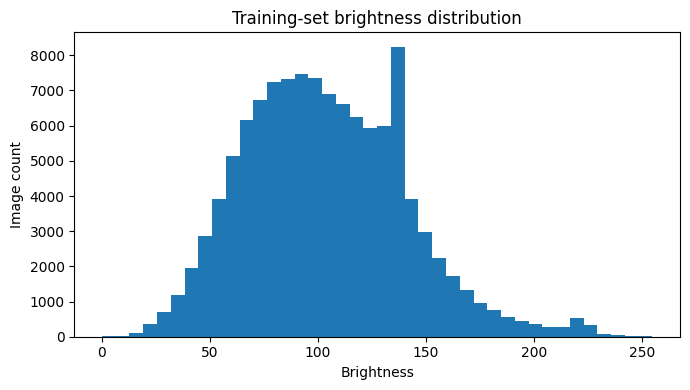

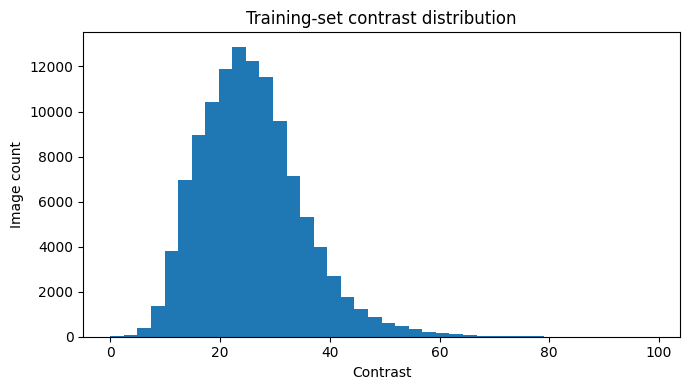

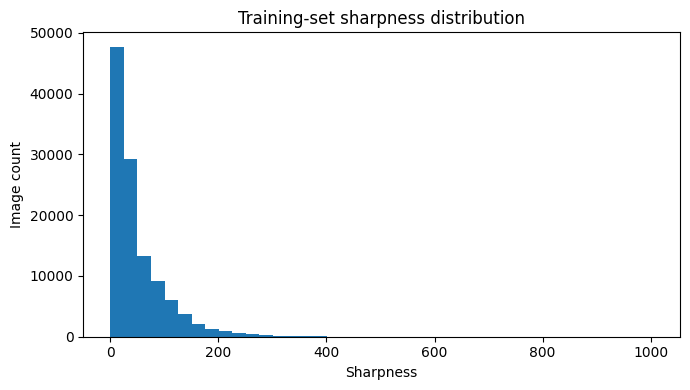

In [ ]:
def image_quality_features(path: Path) -> Dict[str, float]:
    image = Image.open(path).convert("RGB")
    if CFG.crop_black_border:
        image = CropFundusField()(image)

    array = np.asarray(image)
    gray = cv2.cvtColor(array, cv2.COLOR_RGB2GRAY)
    visible = gray[gray > 10]
    if visible.size == 0:
        visible = gray.reshape(-1)

    return {
        "brightness": float(visible.mean()),
        "contrast": float(visible.std()),
        "sharpness": float(cv2.Laplacian(gray, cv2.CV_64F).var()),
    }


def collect_image_paths(split_dir: Path) -> pd.DataFrame:
    records = []
    for class_id in range(CFG.num_classes):
        class_dir = split_dir / str(class_id)
        for path in class_dir.rglob("*"):
            if path.is_file() and path.suffix.lower() in SUPPORTED_EXTENSIONS:
                records.append(
                    {
                        "path": str(path),
                        "class_id": class_id,
                        "class_name": CFG.class_names[class_id],
                    }
                )
    return pd.DataFrame(records)


def quality_audit(
    split_dir: Path,
    sample_size: Optional[int],
    seed: int,
) -> pd.DataFrame:
    paths_df = collect_image_paths(split_dir)
    if sample_size is not None and sample_size < len(paths_df):
        paths_df = paths_df.sample(n=sample_size, random_state=seed)

    rows = []
    for row in tqdm(
        paths_df.itertuples(index=False),
        total=len(paths_df),
        desc="Quality audit",
    ):
        rows.append(
            {
                "path": row.path,
                "class_id": row.class_id,
                "class_name": row.class_name,
                **image_quality_features(Path(row.path)),
            }
        )
    return pd.DataFrame(rows)


if CFG.data_root.exists():
    train_quality = quality_audit(
        CFG.data_root / "train",
        sample_size=CFG.quality_audit_max_images,
        seed=CFG.seed,
    )
    print(
        "Quality audit images:",
        len(train_quality),
        "(complete training set)"
        if CFG.quality_audit_max_images is None
        else "(diagnostic subset only; model training still uses all images)",
    )
    display(
        train_quality.groupby("class_name")[
            ["brightness", "contrast", "sharpness"]
        ].describe()
    )

    for feature in ("brightness", "contrast", "sharpness"):
        plt.figure(figsize=(7, 4))
        plt.hist(train_quality[feature], bins=40)
        plt.xlabel(feature.capitalize())
        plt.ylabel("Image count")
        plt.title(f"Training-set {feature} distribution")
        plt.tight_layout()
        plt.show()
else:
    train_quality = None
    print("Quality audit skipped: set CFG.data_root first.")

In [ ]:
def validate_imagefolder_mapping(
    dataset: ImageFolder,
    split_name: str,
) -> None:
    """Verify that folder names 0-4 map to integer class labels 0-4."""
    expected_mapping = {
        str(class_id): class_id
        for class_id in range(CFG.num_classes)
    }

    if dataset.class_to_idx != expected_mapping:
        raise ValueError(
            f"{split_name} class mapping is {dataset.class_to_idx}; "
            f"expected {expected_mapping}."
        )


def summarize_full_dataset(
    dataset: ImageFolder,
    split_name: str,
    num_classes: int,
) -> pd.DataFrame:
    """Summarize every image loaded from one complete dataset split."""
    targets = np.asarray(dataset.targets, dtype=np.int64)
    counts = np.bincount(targets, minlength=num_classes)
    split_total = int(counts.sum())

    if split_total != len(dataset):
        raise RuntimeError(
            f"{split_name} target count ({split_total}) does not match "
            f"dataset length ({len(dataset)})."
        )

    rows: List[Dict[str, Any]] = []
    for class_id, count in enumerate(counts):
        if count <= 0:
            raise ValueError(
                f"{split_name}/{class_id} contains no supported images."
            )

        rows.append(
            {
                "split": split_name,
                "folder": str(class_id),
                "assigned_label": class_id,
                "available_images": int(count),
                "used_images": int(count),
                "split_percentage": 100.0 * float(count) / split_total,
            }
        )

    return pd.DataFrame(rows)


def compute_class_counts(
    dataset: ImageFolder,
    num_classes: int,
) -> np.ndarray:
    targets = np.asarray(
        dataset.targets,
        dtype=np.int64,
    )
    return np.bincount(
        targets,
        minlength=num_classes,
    )


def effective_number_weights(
    class_counts: Sequence[int],
    beta: float = 0.9999,
) -> torch.Tensor:
    """Compute class-balanced loss weights from the complete training set."""
    counts = np.asarray(
        class_counts,
        dtype=np.float64,
    )

    if np.any(counts <= 0):
        raise ValueError(
            f"Every class must contain samples: {counts}"
        )

    effective_num = 1.0 - np.power(
        beta,
        counts,
    )
    weights = (
        (1.0 - beta)
        / np.maximum(
            effective_num,
            1e-12,
        )
    )
    weights = weights / weights.mean()

    return torch.tensor(
        weights,
        dtype=torch.float32,
    )


def build_datasets_and_loaders(
    cfg: Config,
):
    """
    Load all images from the predefined train, validation, and test folders.

    No class-wise truncation or random subset selection is performed. The
    original split membership and the naturally occurring class distribution
    are preserved exactly as stored on disk.
    """
    train_dataset = ImageFolder(
        root=cfg.data_root / "train",
        transform=train_transform,
    )
    val_dataset = ImageFolder(
        root=cfg.data_root / "val",
        transform=eval_transform,
    )
    test_dataset = ImageFolder(
        root=cfg.data_root / "test",
        transform=eval_transform,
    )

    datasets_by_split = {
        "train": train_dataset,
        "val": val_dataset,
        "test": test_dataset,
    }

    summary_frames = []
    for split_name, dataset in datasets_by_split.items():
        validate_imagefolder_mapping(dataset, split_name)
        summary_frames.append(
            summarize_full_dataset(
                dataset=dataset,
                split_name=split_name,
                num_classes=cfg.num_classes,
            )
        )

    dataset_summary = pd.concat(
        summary_frames,
        ignore_index=True,
    )

    train_counts = compute_class_counts(
        train_dataset,
        cfg.num_classes,
    )

    if np.any(train_counts == 0):
        raise RuntimeError(
            f"At least one training class is empty: {train_counts}."
        )

    class_weights = effective_number_weights(
        train_counts,
        cfg.class_balance_beta,
    )

    # num_workers=0 is safer in Jupyter on Windows.
    worker_count = (
        0
        if os.name == "nt"
        else max(
            0,
            min(
                cfg.num_workers,
                os.cpu_count() or 0,
            ),
        )
    )

    loader_kwargs = {
        "batch_size": cfg.batch_size,
        "num_workers": worker_count,
        "pin_memory": bool(
            cfg.pin_memory
            and torch.cuda.is_available()
        ),
        "persistent_workers": bool(
            cfg.persistent_workers
            and worker_count > 0
        ),
    }

    train_generator = torch.Generator()
    train_generator.manual_seed(cfg.seed)

    train_loader = DataLoader(
        train_dataset,
        shuffle=True,
        generator=train_generator,
        drop_last=False,
        **loader_kwargs,
    )
    val_loader = DataLoader(
        val_dataset,
        shuffle=False,
        drop_last=False,
        **loader_kwargs,
    )
    test_loader = DataLoader(
        test_dataset,
        shuffle=False,
        drop_last=False,
        **loader_kwargs,
    )

    return (
        train_dataset,
        val_dataset,
        test_dataset,
        train_loader,
        val_loader,
        test_loader,
        train_counts,
        class_weights,
        dataset_summary,
    )


if CFG.data_root.exists():
    (
        train_dataset,
        val_dataset,
        test_dataset,
        train_loader,
        val_loader,
        test_loader,
        train_class_counts,
        class_weights,
        dataset_summary,
    ) = build_datasets_and_loaders(CFG)

    print("ImageFolder class mapping:")
    print(train_dataset.class_to_idx)
    print()

    display(dataset_summary)

    print(f"Training images:   {len(train_dataset):,} (all available images)")
    print(f"Validation images: {len(val_dataset):,} (all available images)")
    print(f"Test images:       {len(test_dataset):,} (all available images)")
    print(
        f"Complete experiment size: "
        f"{len(train_dataset) + len(val_dataset) + len(test_dataset):,} images"
    )

    display(
        pd.DataFrame(
            {
                "class": np.arange(CFG.num_classes),
                "complete_training_images": train_class_counts,
                "loss_weight": class_weights.numpy(),
            }
        )
    )

    full_dataset_manifest = pd.concat(
        [
            pd.DataFrame(
                {
                    "split": split_name,
                    "image_path": [
                        path
                        for path, _ in dataset.samples
                    ],
                    "target_class": [
                        int(target)
                        for _, target in dataset.samples
                    ],
                }
            )
            for split_name, dataset in (
                ("train", train_dataset),
                ("val", val_dataset),
                ("test", test_dataset),
            )
        ],
        ignore_index=True,
    )

    expected_manifest_rows = (
        len(train_dataset)
        + len(val_dataset)
        + len(test_dataset)
    )
    if len(full_dataset_manifest) != expected_manifest_rows:
        raise RuntimeError(
            "Full-dataset manifest row count does not match the loaded data."
        )

    full_dataset_manifest.to_csv(
        CFG.manifest_path,
        index=False,
    )

    print(
        "Saved full-dataset manifest:",
        CFG.manifest_path,
    )

    # Explicit sanity check: labels in a training batch must be integers 0-4.
    sample_images, sample_labels = next(
        iter(train_loader)
    )

    print(
        "Training batch image shape:",
        tuple(sample_images.shape),
    )
    print(
        "Unique labels in first batch:",
        sorted(sample_labels.unique().tolist()),
    )
    print(
        "Minimum/maximum batch label:",
        int(sample_labels.min()),
        int(sample_labels.max()),
    )

    if (
        sample_labels.min() < 0
        or sample_labels.max() >= CFG.num_classes
    ):
        raise RuntimeError(
            "The training labels are not restricted to classes 0-4."
        )
else:
    train_dataset = val_dataset = test_dataset = None
    train_loader = val_loader = test_loader = None
    train_class_counts = class_weights = None
    dataset_summary = None
    full_dataset_manifest = None

    print(
        "Dataset was not loaded. "
        "Check CFG.data_root."
    )


ImageFolder class mapping:
{'0': 0, '1': 1, '2': 2, '3': 3, '4': 4}



,split,folder,assigned_label,available_images,used_images,split_percentage
0,train,0,0,55162,55162,47.866645
1,train,1,1,18470,18470,16.027282
2,train,2,2,24198,24198,20.997735
3,train,3,3,7936,7936,6.886438
4,train,4,4,9475,9475,8.221900
5,val,0,0,6895,6895,48.464188
6,val,1,1,1840,1840,12.933155
7,val,2,2,3024,3024,21.255360
8,val,3,3,1000,1000,7.028889
9,val,4,4,1468,1468,10.318409


Training images:   115,241 (all available images)
Validation images: 14,227 (all available images)
Test images:       14,201 (all available images)
Complete experiment size: 143,669 images


,class,complete_training_images,loss_weight
0,0,55162,0.744007
1,1,18470,0.879748
2,2,24198,0.813345
3,3,7936,1.352702
4,4,9475,1.210198


Saved full-dataset manifest: F:\Ml files\DR project\dr_hybrid_outputss\full_dataset_manifest.csv
Training batch image shape: (32, 3, 224, 224)
Unique labels in first batch: [0, 1, 2, 3, 4]
Minimum/maximum batch label: 0 4


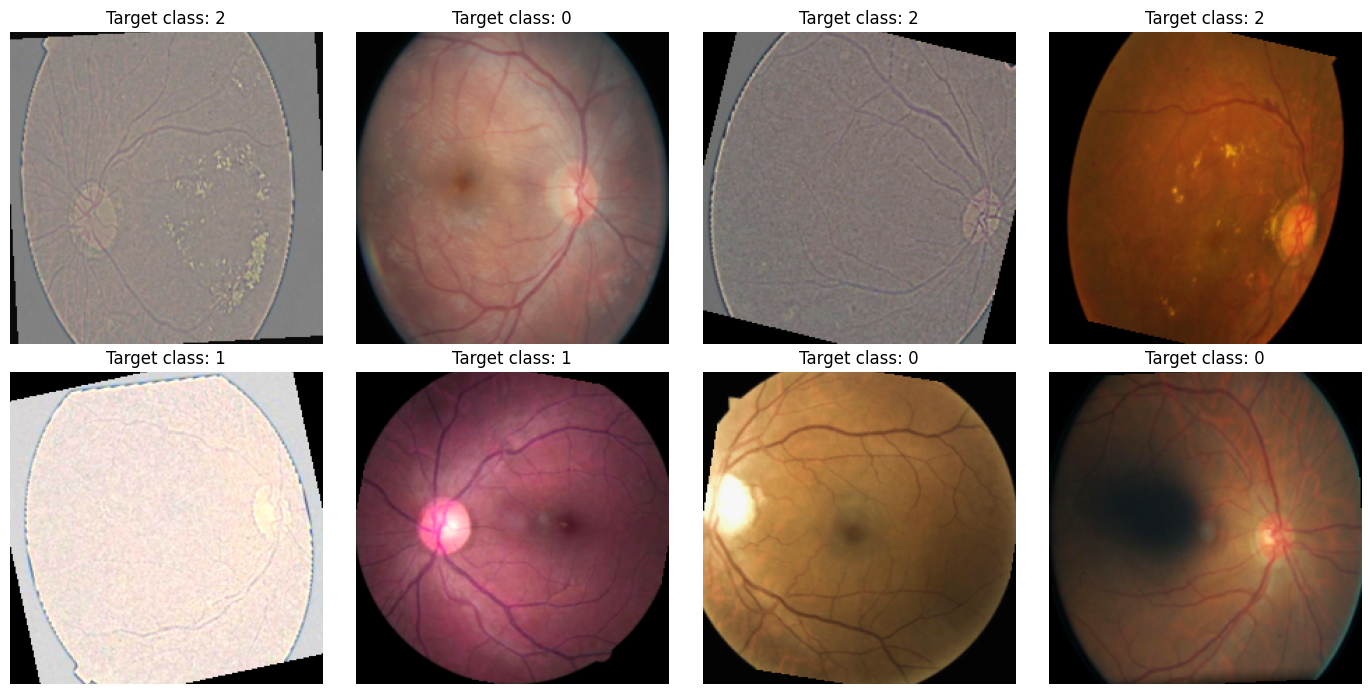

In [ ]:
# Visual verification of image/target pairs.
def denormalize_for_display(image_tensor: torch.Tensor) -> torch.Tensor:
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (image_tensor.cpu() * std + mean).clamp(0, 1)


if train_loader is not None:
    preview_images, preview_targets = next(iter(train_loader))
    number_to_show = min(8, len(preview_images))

    plt.figure(figsize=(14, 7))

    for index in range(number_to_show):
        plt.subplot(2, 4, index + 1)
        image = denormalize_for_display(preview_images[index])
        plt.imshow(image.permute(1, 2, 0))
        plt.title(f"Target class: {int(preview_targets[index])}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("Training data loader is unavailable.")

In [ ]:
class EfficientNetFeatureBackbone(nn.Module):
    def __init__(self, pretrained: bool = True, tap_index: int = 3):
        super().__init__()
        weights = EfficientNet_B0_Weights.IMAGENET1K_V1 if pretrained else None

        try:
            network = efficientnet_b0(weights=weights)
        except Exception as error:
            warnings.warn(
                "Pretrained EfficientNet-B0 weights could not be loaded. "
                f"Using random initialization instead. Original error: {error}"
            )
            network = efficientnet_b0(weights=None)

        self.features = network.features
        self.tap_index = tap_index

        if not 0 <= tap_index < len(self.features):
            raise ValueError(
                f"tap_index={tap_index} is invalid for "
                f"{len(self.features)} feature blocks."
            )

    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        patch_source = None
        for index, block in enumerate(self.features):
            x = block(x)
            if index == self.tap_index:
                patch_source = x

        if patch_source is None:
            raise RuntimeError("Patch feature map was not captured.")
        return patch_source, x


class TransformerEncoderBlock(nn.Module):
    """Pre-normalized Transformer block that stores attention for rollout."""

    def __init__(
        self,
        embed_dim: int,
        num_heads: int,
        mlp_ratio: float,
        attention_dropout: float,
        dropout: float,
    ):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attention = nn.MultiheadAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            dropout=attention_dropout,
            batch_first=True,
        )
        self.residual_dropout = nn.Dropout(dropout)

        hidden_dim = int(embed_dim * mlp_ratio)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, embed_dim),
            nn.Dropout(dropout),
        )
        self.last_attention: Optional[torch.Tensor] = None

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        normalized = self.norm1(x)
        attention_output, attention_weights = self.attention(
            normalized,
            normalized,
            normalized,
            need_weights=True,
            average_attn_weights=False,
        )
        self.last_attention = attention_weights.detach()
        x = x + self.residual_dropout(attention_output)
        x = x + self.mlp(self.norm2(x))
        return x


class HybridCNNViTDR(nn.Module):
    def __init__(self, cfg: Config):
        super().__init__()
        self.cfg = cfg
        self.backbone = EfficientNetFeatureBackbone(
            pretrained=cfg.pretrained_backbone,
            tap_index=cfg.patch_tap_index,
        )

        original_mode = self.backbone.training
        self.backbone.eval()
        with torch.no_grad():
            dummy = torch.zeros(1, 3, cfg.image_size, cfg.image_size)
            patch_source, final_feature = self.backbone(dummy)
        self.backbone.train(original_mode)

        patch_channels = patch_source.shape[1]
        final_channels = final_feature.shape[1]

        self.patch_embedding = nn.Conv2d(
            patch_channels,
            cfg.embed_dim,
            kernel_size=cfg.patch_kernel,
            stride=cfg.patch_stride,
            padding=cfg.patch_padding,
        )

        with torch.no_grad():
            dummy_tokens = self.patch_embedding(patch_source)

        self.patch_grid = (
            int(dummy_tokens.shape[2]),
            int(dummy_tokens.shape[3]),
        )
        self.num_patches = self.patch_grid[0] * self.patch_grid[1]

        self.class_token = nn.Parameter(torch.zeros(1, 1, cfg.embed_dim))
        self.position_embedding = nn.Parameter(
            torch.zeros(1, self.num_patches + 1, cfg.embed_dim)
        )
        self.embedding_dropout = nn.Dropout(cfg.transformer_dropout)

        self.transformer_blocks = nn.ModuleList(
            [
                TransformerEncoderBlock(
                    embed_dim=cfg.embed_dim,
                    num_heads=cfg.num_heads,
                    mlp_ratio=cfg.mlp_ratio,
                    attention_dropout=cfg.attention_dropout,
                    dropout=cfg.transformer_dropout,
                )
                for _ in range(cfg.transformer_depth)
            ]
        )
        self.transformer_norm = nn.LayerNorm(cfg.embed_dim)

        self.spatial_refinement = nn.Sequential(
            nn.Conv2d(
                cfg.embed_dim,
                cfg.embed_dim,
                kernel_size=3,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(cfg.embed_dim),
            nn.GELU(),
        )

        self.cnn_projection = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(final_channels, cfg.embed_dim),
            nn.GELU(),
        )

        fused_dim = 3 * cfg.embed_dim
        self.classifier = nn.Sequential(
            nn.LayerNorm(fused_dim),
            nn.Dropout(cfg.classifier_dropout),
            nn.Linear(fused_dim, cfg.classifier_hidden_dim),
            nn.GELU(),
            nn.Dropout(cfg.classifier_dropout),
            nn.Linear(cfg.classifier_hidden_dim, cfg.num_classes),
        )

        self.backbone_frozen = False
        self._initialize_new_layers()

    def _initialize_new_layers(self) -> None:
        nn.init.trunc_normal_(self.class_token, std=0.02)
        nn.init.trunc_normal_(self.position_embedding, std=0.02)
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.trunc_normal_(module.weight, std=0.02)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)

    def set_backbone_trainable(self, trainable: bool) -> None:
        for parameter in self.backbone.parameters():
            parameter.requires_grad = trainable
        self.backbone_frozen = not trainable
        if self.backbone_frozen:
            self.backbone.eval()

    def train(self, mode: bool = True):
        super().train(mode)
        if self.backbone_frozen:
            self.backbone.eval()
        return self

    def forward_features(self, x: torch.Tensor) -> Dict[str, torch.Tensor]:
        patch_source, final_cnn_feature = self.backbone(x)

        token_map = self.patch_embedding(patch_source)
        batch_size, channels, grid_h, grid_w = token_map.shape

        if (grid_h, grid_w) != self.patch_grid:
            raise RuntimeError(
                f"Unexpected patch grid {(grid_h, grid_w)}; "
                f"expected {self.patch_grid}."
            )

        patch_tokens = token_map.flatten(2).transpose(1, 2)
        class_token = self.class_token.expand(batch_size, -1, -1)
        tokens = torch.cat((class_token, patch_tokens), dim=1)
        tokens = self.embedding_dropout(tokens + self.position_embedding)

        for block in self.transformer_blocks:
            tokens = block(tokens)
        tokens = self.transformer_norm(tokens)

        class_representation = tokens[:, 0]
        spatial_tokens = tokens[:, 1:]
        spatial_map = spatial_tokens.transpose(1, 2).reshape(
            batch_size,
            channels,
            grid_h,
            grid_w,
        )
        refined_map = spatial_map + self.spatial_refinement(spatial_map)
        refined_gap = refined_map.mean(dim=(2, 3))
        cnn_global = self.cnn_projection(final_cnn_feature)

        fused = torch.cat(
            (class_representation, refined_gap, cnn_global),
            dim=1,
        )

        return {
            "fused": fused,
            "class_token": class_representation,
            "refined_map": refined_map,
            "cnn_global": cnn_global,
        }

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        features = self.forward_features(x)
        return self.classifier(features["fused"])

    def get_attention_maps(self) -> List[torch.Tensor]:
        maps = []
        for block in self.transformer_blocks:
            if block.last_attention is None:
                raise RuntimeError(
                    "Run a forward pass before requesting attention maps."
                )
            maps.append(block.last_attention)
        return maps


model = HybridCNNViTDR(CFG).to(DEVICE)

print(model)
print("Patch grid:", model.patch_grid)
print("Number of patch tokens:", model.num_patches)
print(
    "Trainable parameters:",
    f"{sum(p.numel() for p in model.parameters() if p.requires_grad):,}",
)
print(
    "Total parameters:",
    f"{sum(p.numel() for p in model.parameters()):,}",
)

HybridCNNViTDR(
  (backbone): EfficientNetFeatureBackbone(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (1): Sequential(
        (0): MBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
              (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): SiLU(inplace=True)
            )
            (1): SqueezeExcitation(
              (avgpool): AdaptiveAvgPool2d(output_size=1)
              (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
              (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
              (activation): SiLU(inplace=True)
   

In [ ]:
# Confirm that the proposed model is a five-class classifier.
with torch.no_grad():
    dummy_batch = torch.randn(
        2,
        3,
        CFG.image_size,
        CFG.image_size,
        device=DEVICE,
    )
    dummy_logits = model(dummy_batch)
    dummy_predictions = dummy_logits.argmax(dim=1)

print(
    "Model output shape:",
    tuple(dummy_logits.shape),
)
print(
    "Example predicted class IDs:",
    dummy_predictions.tolist(),
)

assert dummy_logits.shape == (
    2,
    5,
), "The model must output exactly five logits."

assert torch.all(
    (dummy_predictions >= 0)
    & (dummy_predictions <= 4)
), "Predictions must be class IDs from 0 to 4."

Model output shape: (2, 5)
Example predicted class IDs: [3, 0]


In [ ]:
class ClassBalancedFocalLoss(nn.Module):
    def __init__(
        self,
        class_weights: torch.Tensor,
        gamma: float = 2.0,
        label_smoothing: float = 0.05,
    ):
        super().__init__()
        if class_weights.ndim != 1:
            raise ValueError("class_weights must be one-dimensional.")

        self.register_buffer("class_weights", class_weights.float())
        self.gamma = float(gamma)
        self.label_smoothing = float(label_smoothing)

    def forward(
        self,
        logits: torch.Tensor,
        targets: torch.Tensor,
    ) -> torch.Tensor:
        num_classes = logits.shape[1]
        log_probabilities = F.log_softmax(logits, dim=1)
        probabilities = log_probabilities.exp()

        one_hot = F.one_hot(
            targets,
            num_classes=num_classes,
        ).float()

        smoothed_targets = (
            one_hot * (1.0 - self.label_smoothing)
            + self.label_smoothing / num_classes
        )

        focal_factor = torch.pow(1.0 - probabilities, self.gamma)

        loss = (
            -smoothed_targets
            * focal_factor
            * log_probabilities
            * self.class_weights.unsqueeze(0)
        )
        return loss.sum(dim=1).mean()


if class_weights is not None:
    criterion = ClassBalancedFocalLoss(
        class_weights=class_weights.to(DEVICE),
        gamma=CFG.focal_gamma,
        label_smoothing=CFG.label_smoothing,
    )
    print(criterion)
else:
    criterion = None

ClassBalancedFocalLoss()


In [ ]:
def safe_multiclass_roc_auc(
    y_true: np.ndarray,
    y_prob: np.ndarray,
) -> float:
    try:
        return float(
            roc_auc_score(
                y_true,
                y_prob,
                multi_class="ovr",
                average="macro",
                labels=np.arange(y_prob.shape[1]),
            )
        )
    except ValueError:
        return float("nan")


def safe_macro_average_precision(
    y_true: np.ndarray,
    y_prob: np.ndarray,
) -> float:
    y_binary = label_binarize(
        y_true,
        classes=np.arange(y_prob.shape[1]),
    )
    try:
        return float(
            average_precision_score(
                y_binary,
                y_prob,
                average="macro",
            )
        )
    except ValueError:
        return float("nan")


def expected_calibration_error(
    y_true: np.ndarray,
    y_prob: np.ndarray,
    n_bins: int = 15,
) -> float:
    confidences = y_prob.max(axis=1)
    predictions = y_prob.argmax(axis=1)
    correctness = predictions == y_true

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0

    for lower, upper in zip(bin_edges[:-1], bin_edges[1:]):
        in_bin = (confidences > lower) & (confidences <= upper)
        if not np.any(in_bin):
            continue

        bin_accuracy = correctness[in_bin].mean()
        bin_confidence = confidences[in_bin].mean()
        ece += np.abs(bin_accuracy - bin_confidence) * in_bin.mean()

    return float(ece)


def multiclass_brier_score(
    y_true: np.ndarray,
    y_prob: np.ndarray,
) -> float:
    y_binary = label_binarize(
        y_true,
        classes=np.arange(y_prob.shape[1]),
    )
    return float(
        np.mean(
            np.sum(
                (y_prob - y_binary) ** 2,
                axis=1,
            )
        )
    )


def compute_classification_metrics(
    y_true: np.ndarray,
    y_prob: np.ndarray,
) -> Tuple[Dict[str, float], pd.DataFrame, np.ndarray]:
    y_pred = y_prob.argmax(axis=1)

    macro_precision, macro_recall, macro_f1, _ = (
        precision_recall_fscore_support(
            y_true,
            y_pred,
            average="macro",
            zero_division=0,
        )
    )

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=np.arange(CFG.num_classes),
    )

    class_rows = []
    for class_id in range(CFG.num_classes):
        true_positive = cm[class_id, class_id]
        false_negative = cm[class_id, :].sum() - true_positive
        false_positive = cm[:, class_id].sum() - true_positive
        true_negative = (
            cm.sum()
            - true_positive
            - false_negative
            - false_positive
        )

        sensitivity = (
            true_positive / (true_positive + false_negative)
            if (true_positive + false_negative)
            else np.nan
        )
        specificity = (
            true_negative / (true_negative + false_positive)
            if (true_negative + false_positive)
            else np.nan
        )

        class_rows.append(
            {
                "class_id": class_id,
                "class_name": CFG.class_names[class_id],
                "support": int(cm[class_id, :].sum()),
                "sensitivity_recall": float(sensitivity),
                "specificity": float(specificity),
            }
        )

    absolute_grade_error = np.abs(y_pred - y_true)

    metrics = {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "macro_precision": float(macro_precision),
        "macro_recall": float(macro_recall),
        "macro_f1": float(macro_f1),
        "mcc": float(matthews_corrcoef(y_true, y_pred)),
        "cohen_kappa": float(cohen_kappa_score(y_true, y_pred)),
        "qwk": float(
            cohen_kappa_score(
                y_true,
                y_pred,
                weights="quadratic",
            )
        ),
        "macro_roc_auc_ovr": safe_multiclass_roc_auc(
            y_true,
            y_prob,
        ),
        "macro_pr_auc": safe_macro_average_precision(
            y_true,
            y_prob,
        ),
        "mean_absolute_grade_error": float(
            absolute_grade_error.mean()
        ),
        "within_one_grade_accuracy": float(
            (absolute_grade_error <= 1).mean()
        ),
        "major_error_rate": float(
            (absolute_grade_error >= 2).mean()
        ),
        "ece_15": expected_calibration_error(
            y_true,
            y_prob,
            n_bins=15,
        ),
        "multiclass_brier": multiclass_brier_score(
            y_true,
            y_prob,
        ),
    }

    return metrics, pd.DataFrame(class_rows), cm


class TemperatureScaler(nn.Module):
    def __init__(self):
        super().__init__()
        self.log_temperature = nn.Parameter(torch.zeros(1))

    @property
    def temperature(self) -> torch.Tensor:
        return self.log_temperature.exp().clamp(0.05, 10.0)

    def forward(self, logits: torch.Tensor) -> torch.Tensor:
        return logits / self.temperature

    def fit(
        self,
        logits: torch.Tensor,
        labels: torch.Tensor,
        max_iter: int = 50,
    ) -> "TemperatureScaler":
        logits = logits.detach()
        labels = labels.detach()
        self.to(logits.device)

        optimizer = torch.optim.LBFGS(
            [self.log_temperature],
            lr=0.1,
            max_iter=max_iter,
            line_search_fn="strong_wolfe",
        )
        criterion_nll = nn.CrossEntropyLoss()

        def closure():
            optimizer.zero_grad(set_to_none=True)
            loss = criterion_nll(self(logits), labels)
            loss.backward()
            return loss

        optimizer.step(closure)
        return self

In [ ]:
def autocast_context():
    if AMP_ENABLED:
        return torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
        )
    return nullcontext()


def create_grad_scaler():
    try:
        return torch.amp.GradScaler(
            "cuda",
            enabled=AMP_ENABLED,
        )
    except Exception:
        return torch.cuda.amp.GradScaler(
            enabled=AMP_ENABLED,
        )


def safe_torch_load(
    path: Path,
    map_location: torch.device,
):
    try:
        return torch.load(
            path,
            map_location=map_location,
            weights_only=False,
        )
    except TypeError:
        return torch.load(
            path,
            map_location=map_location,
        )


def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    criterion: nn.Module,
    scaler,
    cfg: Config,
) -> float:
    model.train()
    total_loss = 0.0
    total_examples = 0

    progress = tqdm(
        loader,
        desc="Training",
        leave=False,
    )

    for batch_index, (images, labels) in enumerate(progress):
        if cfg.fast_dev_run and batch_index >= cfg.fast_dev_batches:
            break

        images = images.to(
            DEVICE,
            non_blocking=True,
        )
        labels = labels.to(
            DEVICE,
            non_blocking=True,
        )

        optimizer.zero_grad(set_to_none=True)

        with autocast_context():
            logits = model(images)

            if logits.ndim != 2 or logits.shape[1] != 5:
                raise RuntimeError(
                    f"Expected model output [batch, 5], got {tuple(logits.shape)}."
                )

            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(
            model.parameters(),
            cfg.gradient_clip_norm,
        )
        scaler.step(optimizer)
        scaler.update()

        batch_size = images.shape[0]
        total_loss += float(loss.detach().item()) * batch_size
        total_examples += batch_size

        progress.set_postfix(
            loss=f"{loss.detach().item():.4f}"
        )

    return total_loss / max(total_examples, 1)


@torch.inference_mode()
def collect_predictions(
    model: nn.Module,
    loader: DataLoader,
    criterion: Optional[nn.Module] = None,
    fast_dev_run: bool = False,
    fast_dev_batches: int = 3,
) -> Dict[str, Any]:
    model.eval()

    all_logits: List[torch.Tensor] = []
    all_labels: List[torch.Tensor] = []
    total_loss = 0.0
    total_examples = 0

    progress = tqdm(
        loader,
        desc="Evaluating",
        leave=False,
    )

    for batch_index, (images, labels) in enumerate(progress):
        if fast_dev_run and batch_index >= fast_dev_batches:
            break

        images = images.to(
            DEVICE,
            non_blocking=True,
        )
        labels = labels.to(
            DEVICE,
            non_blocking=True,
        )

        with autocast_context():
            logits = model(images)

            if logits.ndim != 2 or logits.shape[1] != 5:
                raise RuntimeError(
                    f"Expected model output [batch, 5], got {tuple(logits.shape)}."
                )

            loss = (
                criterion(logits, labels)
                if criterion is not None
                else None
            )

        if loss is not None:
            total_loss += float(loss.item()) * images.shape[0]

        total_examples += images.shape[0]
        all_logits.append(logits.float().cpu())
        all_labels.append(labels.cpu())

    if not all_logits:
        raise RuntimeError("No batches were evaluated.")

    logits_tensor = torch.cat(all_logits)
    labels_tensor = torch.cat(all_labels)
    probabilities = torch.softmax(
        logits_tensor,
        dim=1,
    ).numpy()
    labels_numpy = labels_tensor.numpy()

    metrics, class_metrics, cm = compute_classification_metrics(
        labels_numpy,
        probabilities,
    )
    metrics["loss"] = (
        total_loss / max(total_examples, 1)
        if criterion is not None
        else np.nan
    )

    return {
        "metrics": metrics,
        "class_metrics": class_metrics,
        "confusion_matrix": cm,
        "logits": logits_tensor,
        "labels": labels_tensor,
        "probabilities": probabilities,
    }


def save_checkpoint(
    path: Path,
    model: nn.Module,
    optimizer: torch.optim.Optimizer,
    epoch: int,
    stage: str,
    monitor_value: float,
    cfg: Config,
) -> None:
    path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    torch.save(
        {
            "epoch": epoch,
            "stage": stage,
            "monitor": cfg.monitor,
            "monitor_value": monitor_value,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "config": {
                key: str(value) if isinstance(value, Path) else value
                for key, value in asdict(cfg).items()
            },
        },
        path,
    )


def run_training_stage(
    *,
    stage_name: str,
    model: HybridCNNViTDR,
    train_loader: DataLoader,
    val_loader: DataLoader,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer,
    scheduler,
    epochs: int,
    cfg: Config,
    history: List[Dict[str, Any]],
    best_metric: float,
) -> float:
    scaler = create_grad_scaler()
    epochs_without_improvement = 0

    for epoch in range(1, epochs + 1):
        start_time = time.time()

        train_loss = train_one_epoch(
            model,
            train_loader,
            optimizer,
            criterion,
            scaler,
            cfg,
        )

        validation_result = collect_predictions(
            model,
            val_loader,
            criterion,
            fast_dev_run=cfg.fast_dev_run,
            fast_dev_batches=cfg.fast_dev_batches,
        )

        monitor_value = float(
            validation_result["metrics"][cfg.monitor]
        )
        scheduler.step()

        row = {
            "stage": stage_name,
            "epoch": epoch,
            "train_loss": train_loss,
            **{
                f"val_{key}": value
                for key, value in validation_result["metrics"].items()
            },
            "lr_first_group": optimizer.param_groups[0]["lr"],
            "elapsed_minutes": (
                time.time() - start_time
            ) / 60.0,
        }

        if len(optimizer.param_groups) > 1:
            row["lr_transformer_head"] = (
                optimizer.param_groups[1]["lr"]
            )

        history.append(row)
        pd.DataFrame(history).to_csv(
            cfg.history_path,
            index=False,
        )

        print(
            f"[{stage_name}] Epoch {epoch:03d}/{epochs:03d} | "
            f"train loss={train_loss:.4f} | "
            f"val macro-F1="
            f"{validation_result['metrics']['macro_f1']:.4f} | "
            f"val QWK="
            f"{validation_result['metrics']['qwk']:.4f} | "
            f"val ECE="
            f"{validation_result['metrics']['ece_15']:.4f}"
        )

        if monitor_value > best_metric:
            best_metric = monitor_value
            epochs_without_improvement = 0

            save_checkpoint(
                cfg.checkpoint_path,
                model,
                optimizer,
                epoch,
                stage_name,
                monitor_value,
                cfg,
            )
            print(
                "  Saved improved checkpoint:",
                cfg.checkpoint_path,
            )
        else:
            epochs_without_improvement += 1

        if cfg.fast_dev_run:
            print(
                "FAST_DEV_RUN enabled: stopping after one epoch."
            )
            break

        if (
            epochs_without_improvement
            >= cfg.early_stopping_patience
        ):
            print(
                "Early stopping after "
                f"{epochs_without_improvement} epochs "
                "without validation improvement."
            )
            break

    return best_metric

In [ ]:
history: List[Dict[str, Any]] = []
best_metric = -float("inf")

if CFG.run_training:
    if (
        train_loader is None
        or val_loader is None
        or criterion is None
    ):
        raise RuntimeError(
            "Build the datasets and data loaders before training."
        )

    model.set_backbone_trainable(False)

    warmup_parameters = [
        parameter
        for parameter in model.parameters()
        if parameter.requires_grad
    ]

    warmup_optimizer = torch.optim.AdamW(
        warmup_parameters,
        lr=CFG.warmup_lr,
        weight_decay=CFG.weight_decay,
    )

    warmup_scheduler = (
        torch.optim.lr_scheduler.CosineAnnealingLR(
            warmup_optimizer,
            T_max=max(1, CFG.warmup_epochs),
            eta_min=CFG.warmup_lr * 0.05,
        )
    )

    best_metric = run_training_stage(
        stage_name="warmup",
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=warmup_optimizer,
        scheduler=warmup_scheduler,
        epochs=CFG.warmup_epochs,
        cfg=CFG,
        history=history,
        best_metric=best_metric,
    )
else:
    print(
        "Training is disabled. "
        "Set CFG.run_training=True to run Stage 1."
    )

[warmup] Epoch 001/023 | train loss=0.9089 | val macro-F1=0.3792 | val QWK=0.5497 | val ECE=0.0222
  Saved improved checkpoint: F:\Ml files\DR project\dr_hybrid_outputsest_hybrid_dr_model.pt

[warmup] Epoch 002/023 | train loss=0.7972 | val macro-F1=0.4653 | val QWK=0.6328 | val ECE=0.0901
  Saved improved checkpoint: F:\Ml files\DR project\dr_hybrid_outputsest_hybrid_dr_model.pt

[warmup] Epoch 003/023 | train loss=0.7383 | val macro-F1=0.4769 | val QWK=0.6685 | val ECE=0.1032
  Saved improved checkpoint: F:\Ml files\DR project\dr_hybrid_outputsest_hybrid_dr_model.pt

[warmup] Epoch 004/023 | train loss=0.7256 | val macro-F1=0.4985 | val QWK=0.6696 | val ECE=0.1008
  Saved improved checkpoint: F:\Ml files\DR project\dr_hybrid_outputsest_hybrid_dr_model.pt

[warmup] Epoch 005/023 | train loss=0.7079 | val macro-F1=0.4888 | val QWK=0.6500 | val ECE=0.0721
  No checkpoint improvement.

[warmup] Epoch 006/023 | train loss=0.6914 | val macro-F1=0.4832 | val QWK=0.6674 | val ECE=0.0551


<>:2: SyntaxWarning: invalid escape sequence '\M'
<>:2: SyntaxWarning: invalid escape sequence '\M'
/tmp/ipykernel_837/586084730.py:2: SyntaxWarning: invalid escape sequence '\M'
  Saved improved checkpoint: F:\Ml files\DR project\dr_hybrid_outputs\best_hybrid_dr_model.pt


In [ ]:
if CFG.run_training:
    if CFG.checkpoint_path.exists():
        checkpoint = safe_torch_load(
            CFG.checkpoint_path,
            DEVICE,
        )
        model.load_state_dict(
            checkpoint["model_state_dict"]
        )
        best_metric = max(
            best_metric,
            float(checkpoint["monitor_value"]),
        )

    model.set_backbone_trainable(True)

    backbone_parameters = list(
        model.backbone.parameters()
    )
    transformer_head_parameters = [
        parameter
        for name, parameter in model.named_parameters()
        if not name.startswith("backbone.")
    ]

    warmup_optimizer = torch.optim.AdamW(
        [
            {
                "params": backbone_parameters,
                "lr": CFG.backbone_lr,
            },
            {
                "params": transformer_head_parameters,
                "lr": CFG.transformer_head_lr,
            },
        ],
        weight_decay=CFG.weight_decay,
    )

    warmup_scheduler = (
        torch.optim.lr_scheduler.CosineAnnealingLR(
            warmup_optimizer,
            T_max=max(1, CFG.warmup_epochs),
            eta_min=CFG.backbone_lr * 0.05,
        )
    )

    best_metric = run_training_stage(
        stage_name="full_finetuning",
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=finetune_optimizer,
        scheduler=finetune_scheduler,
        epochs=CFG.finetune_epochs,
        cfg=CFG,
        history=history,
        best_metric=best_metric,
    )
else:
    print(
        "Training is disabled. "
        "Set CFG.run_training=True to run Stage 2."
    )

[full_finetuning] Epoch 001/035 | train loss=0.7444 | val macro-F1=0.5020 | val QWK=0.6738 | val ECE=0.0944
  Saved improved checkpoint: F:\Ml files\DR project\dr_hybrid_outputsest_hybrid_dr_model.pt

[full_finetuning] Epoch 002/035 | train loss=0.6956 | val macro-F1=0.5444 | val QWK=0.7066 | val ECE=0.1328
  Saved improved checkpoint: F:\Ml files\DR project\dr_hybrid_outputsest_hybrid_dr_model.pt

[full_finetuning] Epoch 003/035 | train loss=0.6495 | val macro-F1=0.5529 | val QWK=0.7045 | val ECE=0.1201
  No checkpoint improvement.

[full_finetuning] Epoch 004/035 | train loss=0.6304 | val macro-F1=0.5559 | val QWK=0.7117 | val ECE=0.1001
  Saved improved checkpoint: F:\Ml files\DR project\dr_hybrid_outputsest_hybrid_dr_model.pt

[full_finetuning] Epoch 005/035 | train loss=0.6220 | val macro-F1=0.5512 | val QWK=0.7032 | val ECE=0.0865
  No checkpoint improvement.

[full_finetuning] Epoch 006/035 | train loss=0.5982 | val macro-F1=0.5610 | val QWK=0.7266 | val ECE=0.0889
  Saved im

<>:2: SyntaxWarning: invalid escape sequence '\M'
<>:2: SyntaxWarning: invalid escape sequence '\M'
/tmp/ipykernel_837/675998211.py:2: SyntaxWarning: invalid escape sequence '\M'
  Saved improved checkpoint: F:\Ml files\DR project\dr_hybrid_outputs\best_hybrid_dr_model.pt


In [ ]:
def selected_test_paths() -> np.ndarray:
    if not hasattr(test_dataset, "samples"):
        raise AttributeError("test_dataset must expose ImageFolder-style samples.")
    return np.asarray([path for path, _ in test_dataset.samples])


@torch.inference_mode()
def collect_all_predictions() -> Dict[str, Any]:
    targets_list = []
    final_list = []
    cnn_list = []
    transformer_list = []
    spatial_list = []

    for batch in tqdm(test_loader, desc="Collecting test predictions"):
        images, targets = unpack_batch(batch)
        images = images.to(DEVICE, non_blocking=True)

        features = feature_components(images)
        final_logits = model.classifier(features["fused"])
        probe_logits = probe_heads(features)

        targets_list.append(targets.cpu())
        final_list.append(torch.softmax(final_logits, dim=1).cpu())
        cnn_list.append(torch.softmax(probe_logits["cnn"], dim=1).cpu())
        transformer_list.append(
            torch.softmax(probe_logits["transformer"], dim=1).cpu()
        )
        spatial_list.append(torch.softmax(probe_logits["spatial"], dim=1).cpu())

    targets = torch.cat(targets_list).numpy()
    final = torch.cat(final_list).numpy()
    cnn = torch.cat(cnn_list).numpy()
    transformer = torch.cat(transformer_list).numpy()
    spatial = torch.cat(spatial_list).numpy()
    paths = selected_test_paths()[: len(targets)]

    entropy = -np.sum(final * np.log(final + 1e-12), axis=1) / np.log(5)

    frame = pd.DataFrame(
        {
            "image_path": paths,
            "true_class": targets,
            "predicted_class": final.argmax(axis=1),
            "confidence": final.max(axis=1),
            "entropy": entropy,
            "absolute_error": np.abs(final.argmax(axis=1) - targets),
            "cnn_predicted_class": cnn.argmax(axis=1),
            "transformer_predicted_class": transformer.argmax(axis=1),
            "spatial_predicted_class": spatial.argmax(axis=1),
        }
    )

    for class_id in range(5):
        frame[f"probability_class_{class_id}"] = final[:, class_id]

    return {
        "frame": frame,
        "targets": targets,
        "paths": paths,
        "final": final,
        "cnn": cnn,
        "transformer": transformer,
        "spatial": spatial,
    }


PRED = collect_all_predictions()

In [ ]:
def save_figure(figure: plt.Figure, stem: str) -> None:
    for extension in ("png", "pdf", "svg"):
        path = FIGURE_OUTPUT_DIR / f"{stem}.{extension}"
        if extension == "png":
            figure.savefig(path, dpi=EXPORT_DPI)
        else:
            figure.savefig(path)
        print("Saved:", path)


def load_display_image(path: str | Path) -> np.ndarray:
    image = Image.open(path).convert("RGB")

    if "CropFundusField" in globals():
        image = CropFundusField()(image)

    size = int(getattr(globals().get("CFG", None), "image_size", 224))
    image = image.resize((size, size), Image.Resampling.BILINEAR)
    return np.asarray(image, dtype=np.float32) / 255.0


def model_tensor(path: str | Path) -> torch.Tensor:
    image = Image.open(path).convert("RGB")
    return eval_transform(image).unsqueeze(0).to(DEVICE)


def probability_bars(
    axis: plt.Axes,
    probabilities: np.ndarray,
    title: str,
    true_class: Optional[int] = None,
) -> None:
    axis.bar(CLASS_IDS, probabilities)
    axis.set_xticks(CLASS_IDS)
    axis.set_ylim(0, 1)
    axis.set_xlabel("Class")
    axis.set_ylabel("Probability")
    axis.set_title(title)

    if true_class is not None:
        axis.axvline(true_class, linestyle="--", linewidth=1)


def panel_label(axis: plt.Axes, label: str) -> None:
    axis.text(
        -0.10,
        1.08,
        label,
        transform=axis.transAxes,
        fontsize=12,
        fontweight="bold",
        va="top",
    )


class GradCAMPlusPlus:
    def __init__(self, network: nn.Module, target_layer: nn.Module):
        self.network = network
        self.activations = None
        self.gradients = None
        self.handle = target_layer.register_forward_hook(self._hook)

    def _hook(self, module, inputs, output):
        self.activations = output
        if output.requires_grad:
            output.register_hook(self._save_gradient)

    def _save_gradient(self, gradient):
        self.gradients = gradient

    def remove(self):
        self.handle.remove()

    def generate(
        self,
        input_tensor: torch.Tensor,
        target_class: Optional[int] = None,
    ) -> np.ndarray:
        self.network.eval()
        self.network.zero_grad(set_to_none=True)

        logits = self.network(input_tensor)
        if target_class is None:
            target_class = int(logits.argmax(dim=1).item())

        logits[:, target_class].sum().backward(retain_graph=True)

        activations = self.activations
        gradients = self.gradients
        if activations is None or gradients is None:
            raise RuntimeError("Grad-CAM++ failed to capture gradients.")

        grad2 = gradients.pow(2)
        grad3 = gradients.pow(3)
        denominator = 2 * grad2 + (activations * grad3).sum(
            dim=(2, 3), keepdim=True
        )
        denominator = torch.where(
            denominator.abs() > 1e-8,
            denominator,
            torch.ones_like(denominator),
        )

        alpha = grad2 / denominator
        weights = (alpha * F.relu(gradients)).sum(
            dim=(2, 3), keepdim=True
        )
        heatmap = F.relu((weights * activations).sum(dim=1, keepdim=True))
        heatmap = F.interpolate(
            heatmap,
            size=input_tensor.shape[-2:],
            mode="bilinear",
            align_corners=False,
        ).squeeze()

        heatmap = heatmap - heatmap.min()
        heatmap = heatmap / (heatmap.max() + 1e-8)
        return heatmap.detach().cpu().numpy()


def attention_maps_after_forward(input_tensor: torch.Tensor):
    if hasattr(model, "set_attention_capture"):
        model.set_attention_capture(True)

    with torch.no_grad():
        _ = model(input_tensor)

    if hasattr(model, "get_attention_maps"):
        maps = model.get_attention_maps()
    else:
        maps = [
            block.last_attention
            for block in model.transformer_blocks
            if getattr(block, "last_attention", None) is not None
        ]

    if hasattr(model, "set_attention_capture"):
        model.set_attention_capture(False)

    if not maps:
        raise RuntimeError(
            "Attention weights are unavailable. Ensure Transformer blocks "
            "store last_attention during a forward pass."
        )

    return maps


def attention_rollout(
    maps: Sequence[torch.Tensor],
    output_size: Tuple[int, int],
) -> np.ndarray:
    result = torch.eye(maps[0].shape[-1], device=maps[0].device)

    for attention in maps:
        average = attention[0].mean(dim=0)
        identity = torch.eye(average.shape[-1], device=average.device)
        average = average + identity
        average = average / average.sum(dim=-1, keepdim=True)
        result = average @ result

    grid = getattr(model, "patch_grid", None)
    if grid is None:
        number_of_patches = result.shape[-1] - 1
        side = int(round(math.sqrt(number_of_patches)))
        grid = (side, side)

    cls_attention = result[0, 1:].reshape(1, 1, grid[0], grid[1])
    heatmap = F.interpolate(
        cls_attention,
        size=output_size,
        mode="bilinear",
        align_corners=False,
    ).squeeze()

    heatmap = heatmap - heatmap.min()
    heatmap = heatmap / (heatmap.max() + 1e-8)
    return heatmap.detach().cpu().numpy()


def overlay(image: np.ndarray, heatmap: np.ndarray, alpha: float = 0.4):
    colored = plt.cm.jet(heatmap)[..., :3]
    return np.clip((1 - alpha) * image + alpha * colored, 0, 1)


def explanations(path: str | Path, target_class: int):
    tensor = model_tensor(path)
    cam = GradCAMPlusPlus(model, model.backbone.features[-1])

    try:
        gradcam = cam.generate(tensor, target_class)
    finally:
        cam.remove()

    rollout = attention_rollout(
        attention_maps_after_forward(tensor),
        (tensor.shape[-2], tensor.shape[-1]),
    )
    return gradcam, rollout


def top_indices(mask: np.ndarray, score: np.ndarray, n: int):
    candidates = np.flatnonzero(mask)
    if len(candidates) == 0:
        return np.array([], dtype=int)
    ranked = candidates[np.argsort(score[candidates])[::-1]]
    return ranked[:n]

Saved: F:\Ml files\DR project\dr_hybrid_outputs\prediction_level_figures\Figure_01_Local_Global_Prediction_Agreement.png
Saved: F:\Ml files\DR project\dr_hybrid_outputs\prediction_level_figures\Figure_01_Local_Global_Prediction_Agreement.pdf
Saved: F:\Ml files\DR project\dr_hybrid_outputs\prediction_level_figures\Figure_01_Local_Global_Prediction_Agreement.svg


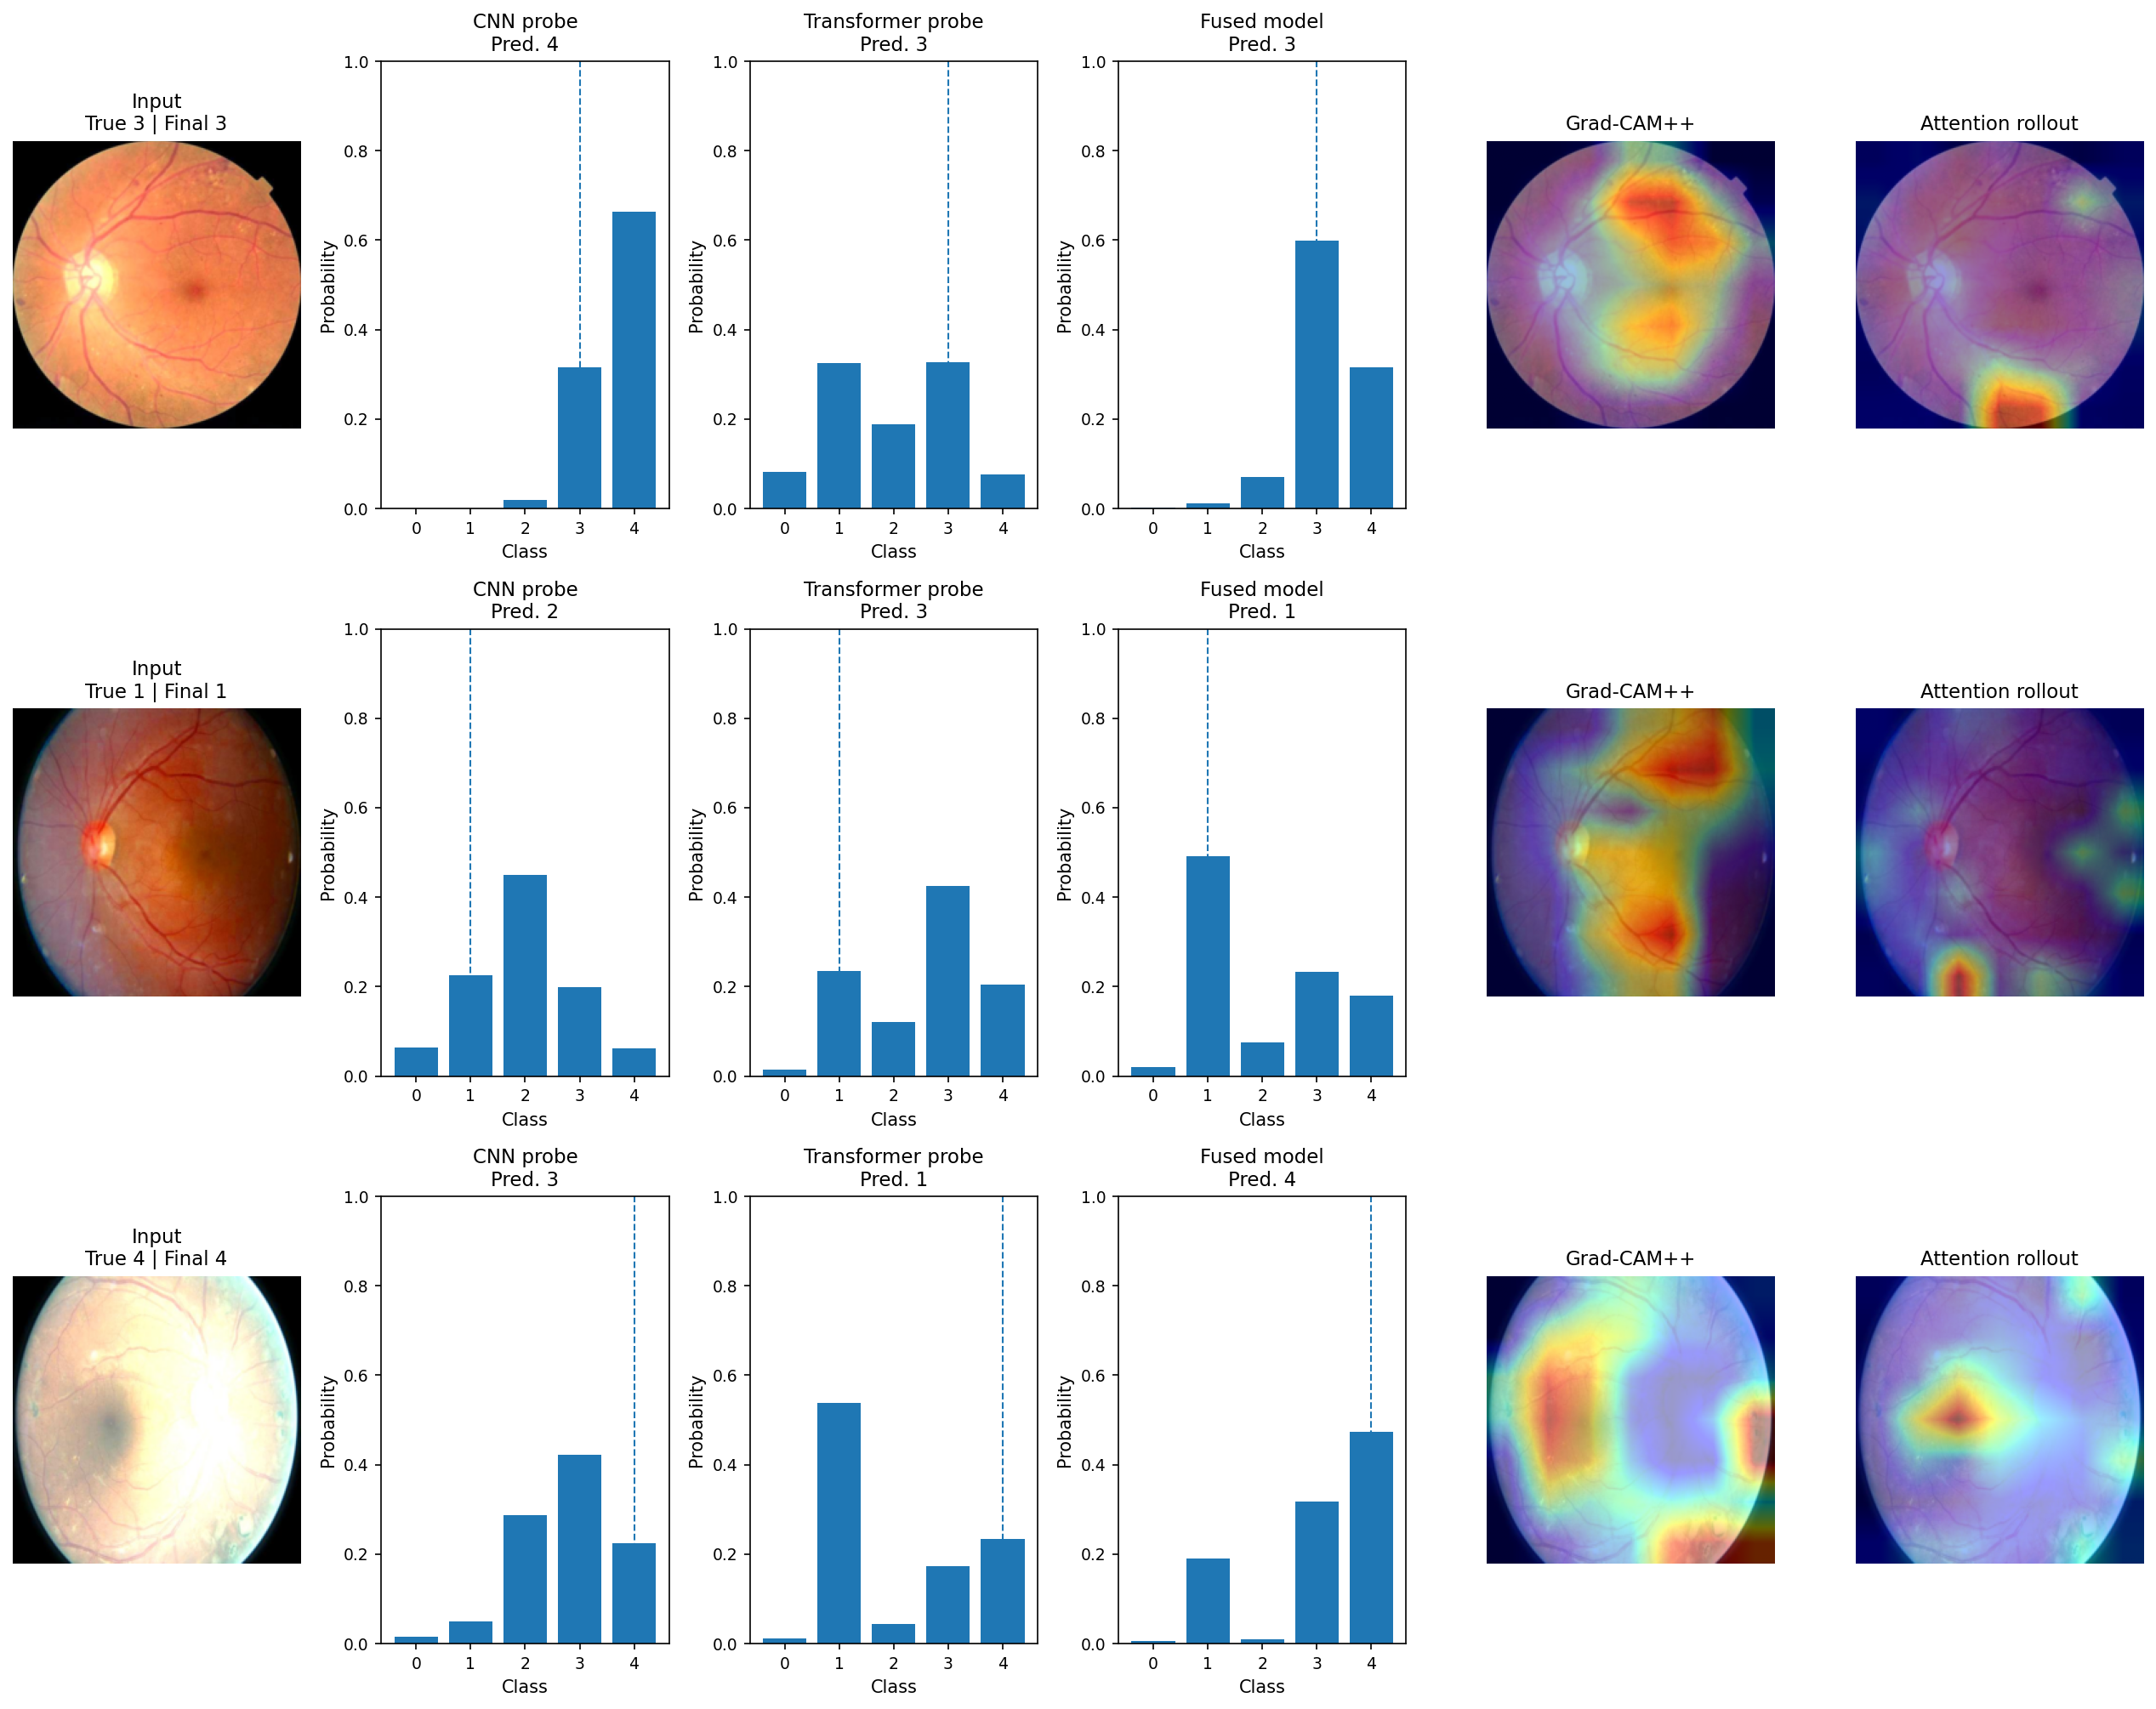

In [ ]:
def make_figure_01(pred: Dict[str, Any], n: int = 3):
    y = pred["targets"]
    final = pred["final"]
    cnn = pred["cnn"]
    transformer = pred["transformer"]
    paths = pred["paths"]

    final_pred = final.argmax(1)
    cnn_pred = cnn.argmax(1)
    transformer_pred = transformer.argmax(1)

    mask = (cnn_pred != transformer_pred) & (final_pred == y)
    row = np.arange(len(y))
    score = final[row, y] - np.maximum(cnn[row, y], transformer[row, y])
    indices = top_indices(mask, score, n)

    if len(indices) == 0:
        print("Figure 1 skipped: no suitable disagreement/recovery cases.")
        return None

    fig, axes = plt.subplots(
        len(indices), 6, figsize=(17, 4.5 * len(indices)), squeeze=False
    )

    for r, index in enumerate(indices):
        image = load_display_image(paths[index])
        gradcam, rollout = explanations(paths[index], int(final_pred[index]))

        axes[r, 0].imshow(image)
        axes[r, 0].axis("off")
        axes[r, 0].set_title(
            f"Input\nTrue {y[index]} | Final {final_pred[index]}"
        )

        probability_bars(
            axes[r, 1], cnn[index],
            f"CNN probe\nPred. {cnn_pred[index]}", int(y[index])
        )
        probability_bars(
            axes[r, 2], transformer[index],
            f"Transformer probe\nPred. {transformer_pred[index]}", int(y[index])
        )
        probability_bars(
            axes[r, 3], final[index],
            f"Fused model\nPred. {final_pred[index]}", int(y[index])
        )

        axes[r, 4].imshow(overlay(image, gradcam))
        axes[r, 4].axis("off")
        axes[r, 4].set_title("Grad-CAM++")

        axes[r, 5].imshow(overlay(image, rollout))
        axes[r, 5].axis("off")
        axes[r, 5].set_title("Attention rollout")

    plt.tight_layout()
    save_figure(fig, "Figure_01_Local_Global_Prediction_Agreement")
    plt.show()
    return fig


figure_01 = make_figure_01(PRED, EXAMPLES_PER_FIGURE)

In [ ]:
def make_figure_02(
    pred: Dict[str, Any],
    baseline_csv: Optional[Path],
    n: int = 3,
):
    if baseline_csv is None or not Path(baseline_csv).exists():
        print(
            "Figure 2 skipped. Set BASELINE_PREDICTIONS_CSV to a CSV containing "
            "baseline probabilities and predictions."
        )
        return None

    baseline = pd.read_csv(baseline_csv)
    required = {
        "image_path",
        "true_class",
        "predicted_class",
        *{f"probability_class_{c}" for c in range(5)},
    }
    missing = required - set(baseline.columns)
    if missing:
        raise ValueError(f"Baseline CSV missing columns: {sorted(missing)}")

    proposed = pred["frame"].copy()
    proposed["proposed_index"] = np.arange(len(proposed))

    merged = proposed.merge(
        baseline,
        on="image_path",
        suffixes=("_proposed", "_baseline"),
    )

    recovered = merged[
        (merged["predicted_class_baseline"] != merged["true_class_proposed"])
        & (merged["predicted_class_proposed"] == merged["true_class_proposed"])
    ].copy()

    if recovered.empty:
        print("Figure 2 skipped: no recovered baseline failures.")
        return None

    baseline_columns = [
        f"probability_class_{c}_baseline" for c in range(5)
    ]
    recovered["baseline_confidence"] = recovered[baseline_columns].max(1)
    recovered = recovered.nlargest(n, "baseline_confidence")

    fig, axes = plt.subplots(
        len(recovered), 5, figsize=(15, 4.5 * len(recovered)), squeeze=False
    )

    for r, (_, sample) in enumerate(recovered.iterrows()):
        path = sample["image_path"]
        index = int(sample["proposed_index"])
        image = load_display_image(path)
        gradcam, rollout = explanations(
            path, int(sample["predicted_class_proposed"])
        )

        axes[r, 0].imshow(image)
        axes[r, 0].axis("off")
        axes[r, 0].set_title(
            f"Input\nTrue {int(sample['true_class_proposed'])}"
        )

        probability_bars(
            axes[r, 1],
            sample[baseline_columns].to_numpy(float),
            f"Baseline failure\nPred. {int(sample['predicted_class_baseline'])}",
            int(sample["true_class_proposed"]),
        )
        probability_bars(
            axes[r, 2],
            pred["final"][index],
            f"Hybrid recovery\nPred. {int(sample['predicted_class_proposed'])}",
            int(sample["true_class_proposed"]),
        )

        axes[r, 3].imshow(overlay(image, gradcam))
        axes[r, 3].axis("off")
        axes[r, 3].set_title("Grad-CAM++")

        axes[r, 4].imshow(overlay(image, rollout))
        axes[r, 4].axis("off")
        axes[r, 4].set_title("Attention rollout")

    plt.tight_layout()
    save_figure(fig, "Figure_02_Baseline_Failure_Hybrid_Recovery")
    plt.show()
    return fig


figure_02 = make_figure_02(
    PRED,
    BASELINE_PREDICTIONS_CSV,
    EXAMPLES_PER_FIGURE,
)

Figure 2 skipped. Set BASELINE_PREDICTIONS_CSV to a CSV containing baseline probabilities and predictions.


Saved: F:\Ml files\DR project\dr_hybrid_outputs\prediction_level_figures\Figure_03_Progressive_Prediction_Refinement.png
Saved: F:\Ml files\DR project\dr_hybrid_outputs\prediction_level_figures\Figure_03_Progressive_Prediction_Refinement.pdf
Saved: F:\Ml files\DR project\dr_hybrid_outputs\prediction_level_figures\Figure_03_Progressive_Prediction_Refinement.svg


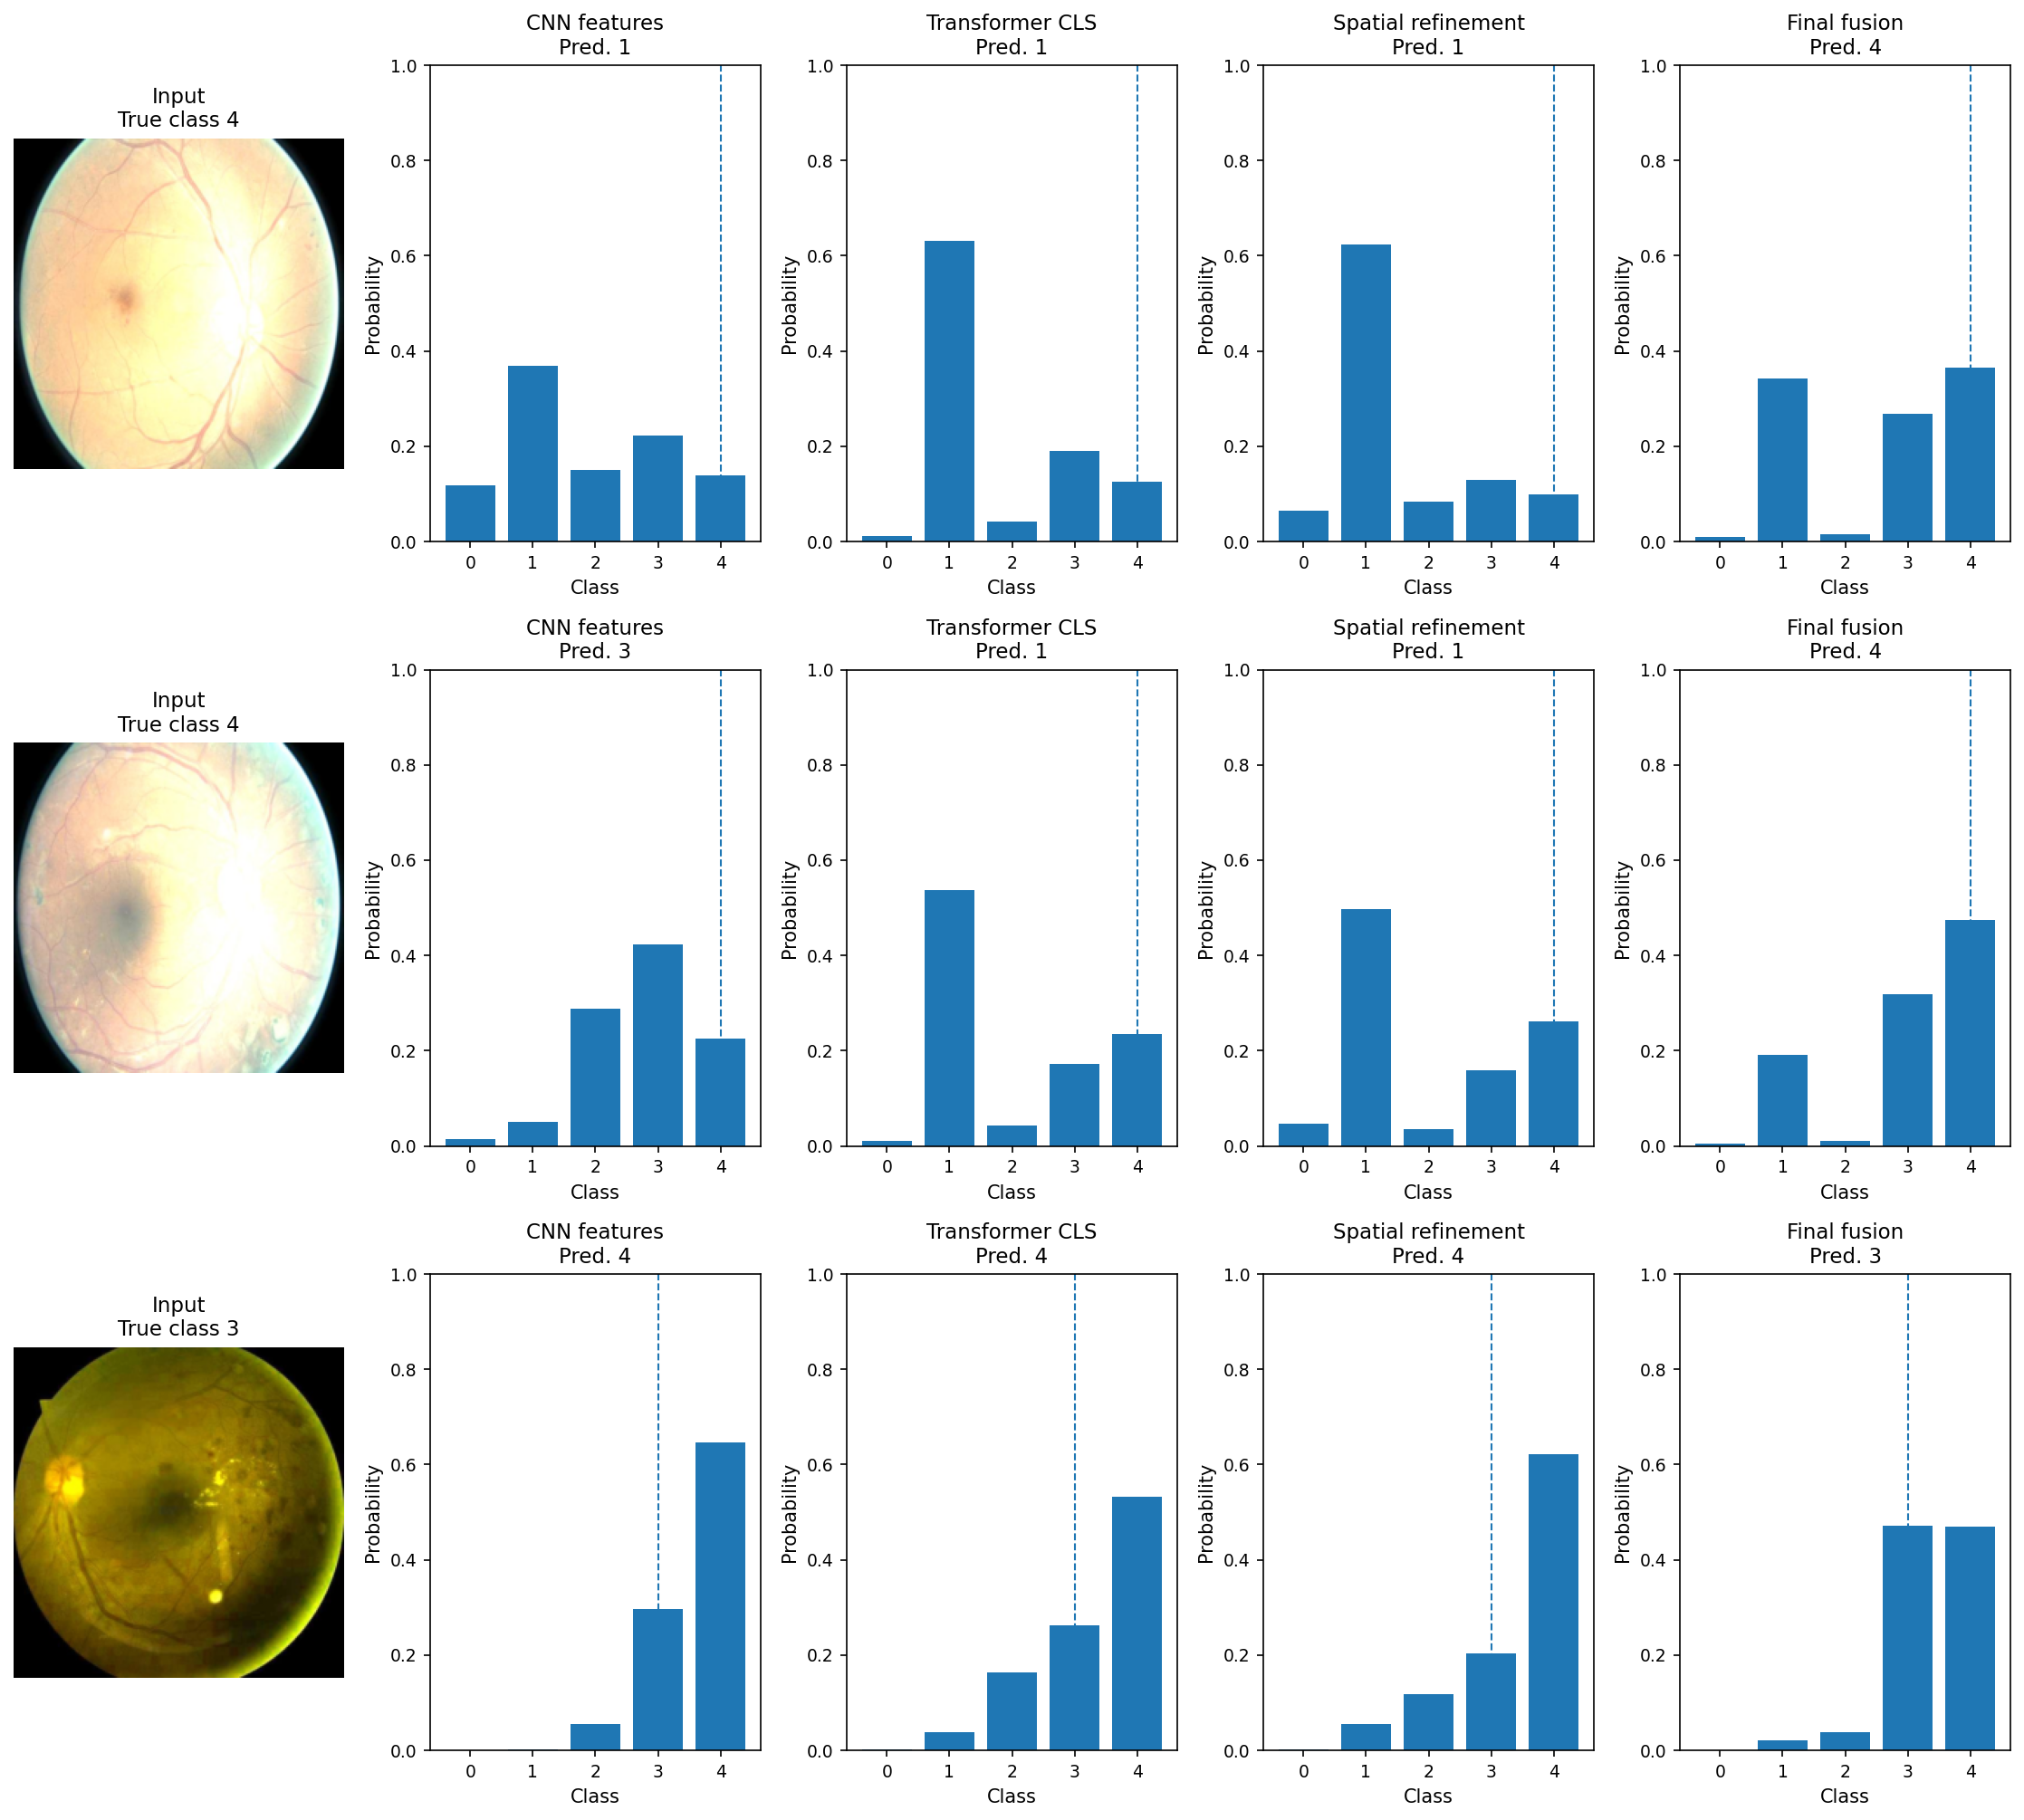

In [ ]:
def make_figure_03(pred: Dict[str, Any], n: int = 3):
    y = pred["targets"]
    final = pred["final"]
    cnn = pred["cnn"]
    transformer = pred["transformer"]
    spatial = pred["spatial"]
    paths = pred["paths"]

    final_pred = final.argmax(1)
    cnn_pred = cnn.argmax(1)
    transformer_pred = transformer.argmax(1)
    spatial_pred = spatial.argmax(1)

    mask = (
        (final_pred == y)
        & (
            (cnn_pred != y)
            | (transformer_pred != y)
            | (spatial_pred != y)
        )
    )

    row = np.arange(len(y))
    branch_true_probability = np.maximum.reduce(
        [
            cnn[row, y],
            transformer[row, y],
            spatial[row, y],
        ]
    )
    score = final[row, y] - branch_true_probability
    indices = top_indices(mask, score, n)

    if len(indices) == 0:
        print("Figure 3 skipped: no suitable progressive-refinement cases.")
        return None

    fig, axes = plt.subplots(
        len(indices), 5, figsize=(15, 4.5 * len(indices)), squeeze=False
    )

    for r, index in enumerate(indices):
        image = load_display_image(paths[index])

        axes[r, 0].imshow(image)
        axes[r, 0].axis("off")
        axes[r, 0].set_title(f"Input\nTrue class {y[index]}")

        probability_bars(
            axes[r, 1], cnn[index],
            f"CNN features\nPred. {cnn_pred[index]}", int(y[index])
        )
        probability_bars(
            axes[r, 2], transformer[index],
            f"Transformer CLS\nPred. {transformer_pred[index]}", int(y[index])
        )
        probability_bars(
            axes[r, 3], spatial[index],
            f"Spatial refinement\nPred. {spatial_pred[index]}", int(y[index])
        )
        probability_bars(
            axes[r, 4], final[index],
            f"Final fusion\nPred. {final_pred[index]}", int(y[index])
        )

    plt.tight_layout()
    save_figure(fig, "Figure_03_Progressive_Prediction_Refinement")
    plt.show()
    return fig


figure_03 = make_figure_03(PRED, EXAMPLES_PER_FIGURE)

C:\Users\Ovi\AppData\Local\Temp\ipykernel_21168\1176224813.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


Saved: F:\Ml files\DR project\dr_hybrid_outputs\prediction_level_figures\Figure_04_Confidence_Error_Severity.png
Saved: F:\Ml files\DR project\dr_hybrid_outputs\prediction_level_figures\Figure_04_Confidence_Error_Severity.pdf
Saved: F:\Ml files\DR project\dr_hybrid_outputs\prediction_level_figures\Figure_04_Confidence_Error_Severity.svg


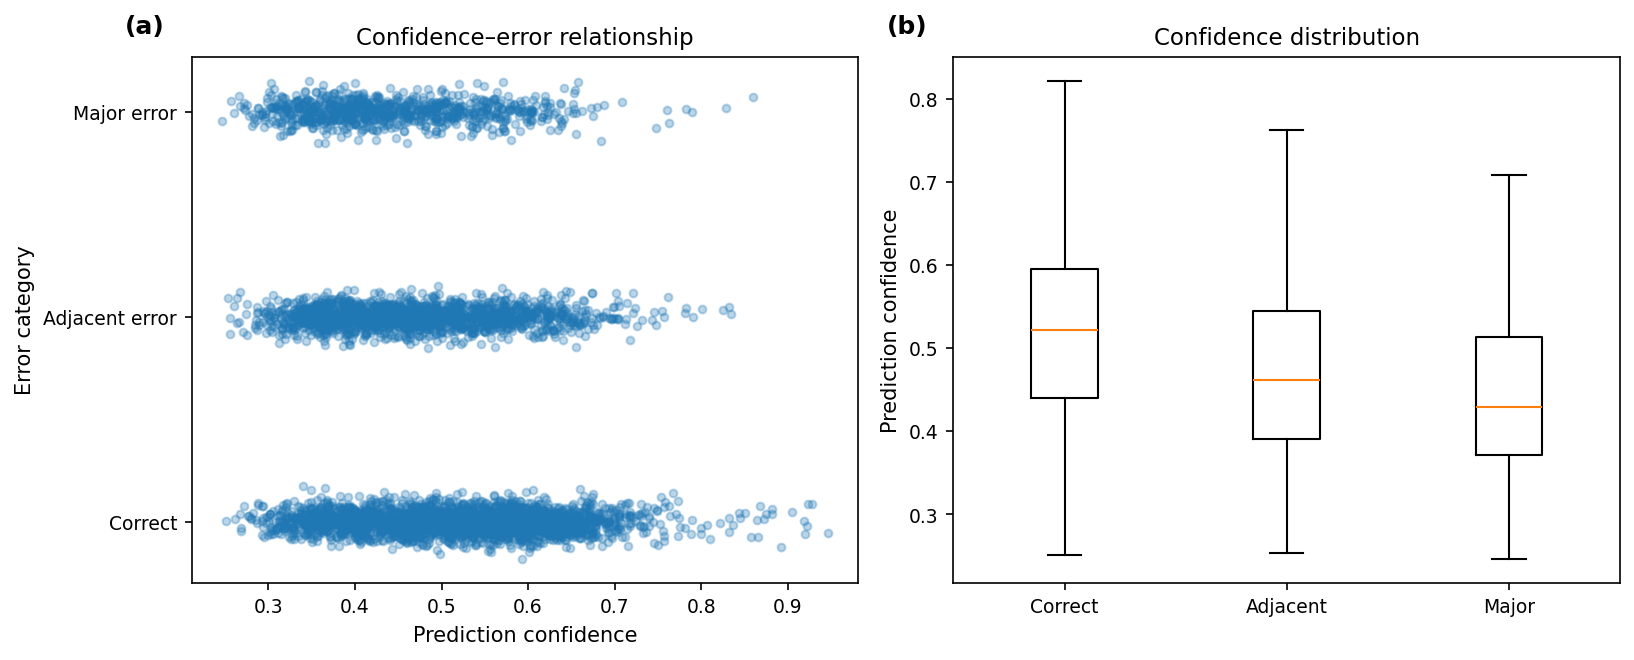

In [ ]:
def make_figure_04(frame: pd.DataFrame):
    categories = np.where(
        frame["absolute_error"].to_numpy() == 0,
        0,
        np.where(frame["absolute_error"].to_numpy() == 1, 1, 2),
    )
    jitter = np.random.default_rng(SEED).normal(0, 0.05, len(frame))

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

    axes[0].scatter(
        frame["confidence"],
        categories + jitter,
        alpha=0.30,
        s=14,
    )
    axes[0].set_yticks(
        [0, 1, 2],
        ["Correct", "Adjacent error", "Major error"],
    )
    axes[0].set_xlabel("Prediction confidence")
    axes[0].set_ylabel("Error category")
    axes[0].set_title("Confidence–error relationship")

    data = [
        frame.loc[categories == category, "confidence"].to_numpy()
        for category in (0, 1, 2)
    ]
    axes[1].boxplot(
        data,
        labels=["Correct", "Adjacent", "Major"],
        showfliers=False,
    )
    axes[1].set_ylabel("Prediction confidence")
    axes[1].set_title("Confidence distribution")

    panel_label(axes[0], "(a)")
    panel_label(axes[1], "(b)")

    plt.tight_layout()
    save_figure(fig, "Figure_04_Confidence_Error_Severity")
    plt.show()
    return fig


figure_04 = make_figure_04(PRED["frame"])

Saved: F:\Ml files\DR project\dr_hybrid_outputs\prediction_level_figures\Figure_05_Adjacent_Grade_Decision_Boundaries.png
Saved: F:\Ml files\DR project\dr_hybrid_outputs\prediction_level_figures\Figure_05_Adjacent_Grade_Decision_Boundaries.pdf
Saved: F:\Ml files\DR project\dr_hybrid_outputs\prediction_level_figures\Figure_05_Adjacent_Grade_Decision_Boundaries.svg


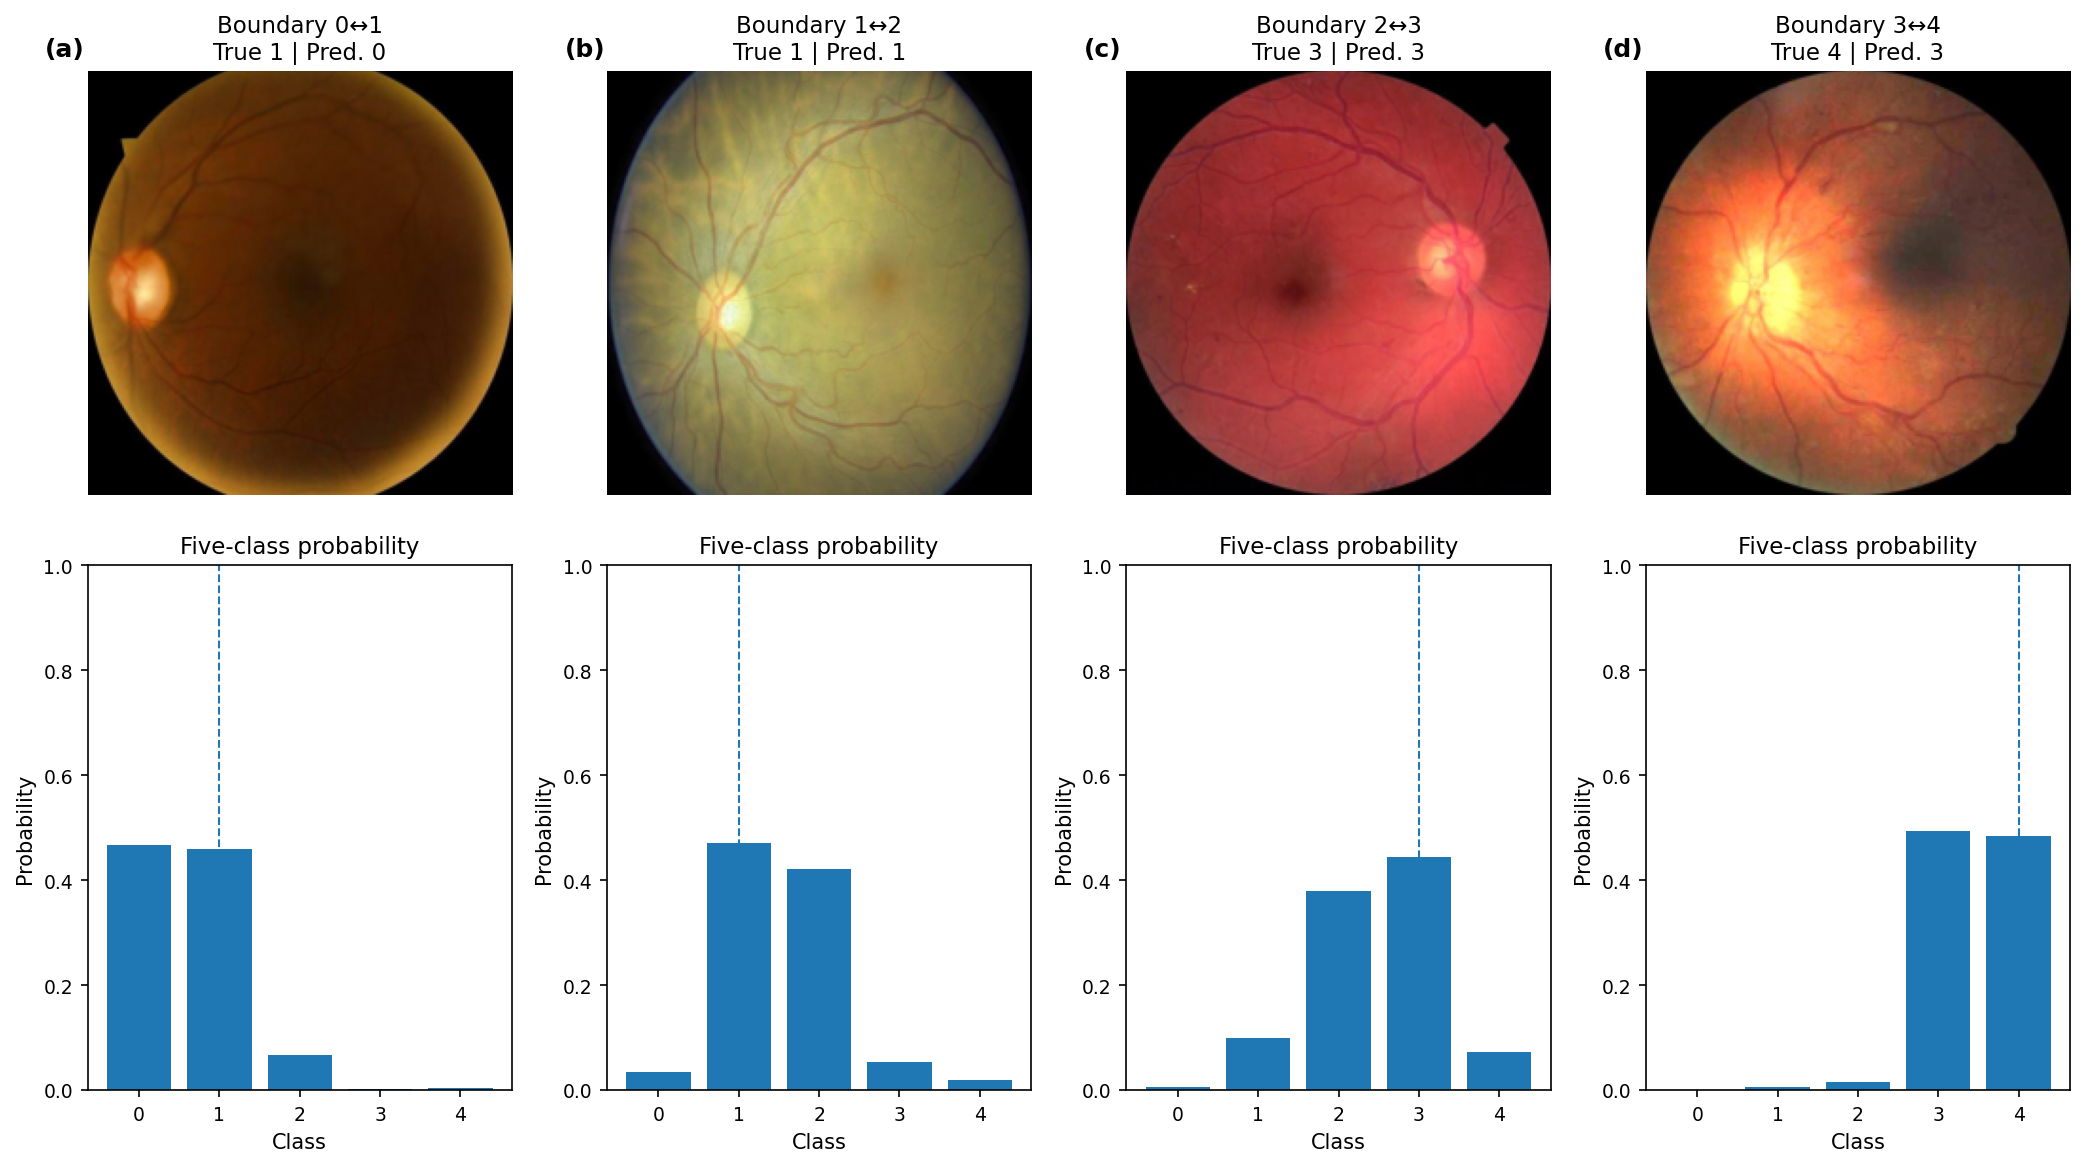

In [ ]:
def make_figure_05(pred: Dict[str, Any]):
    y = pred["targets"]
    probabilities = pred["final"]
    paths = pred["paths"]
    pairs = [(0, 1), (1, 2), (2, 3), (3, 4)]
    selected = []

    for a, b in pairs:
        candidates = np.flatnonzero(np.isin(y, [a, b]))
        pair_mass = probabilities[:, a] + probabilities[:, b]
        margin = np.abs(probabilities[:, a] - probabilities[:, b])
        score = pair_mass - margin
        selected.append(candidates[np.argmax(score[candidates])])

    fig, axes = plt.subplots(2, 4, figsize=(14, 8))

    for column, (index, pair) in enumerate(zip(selected, pairs)):
        image = load_display_image(paths[index])
        axes[0, column].imshow(image)
        axes[0, column].axis("off")
        axes[0, column].set_title(
            f"Boundary {pair[0]}↔{pair[1]}\n"
            f"True {y[index]} | Pred. {probabilities[index].argmax()}"
        )

        probability_bars(
            axes[1, column],
            probabilities[index],
            "Five-class probability",
            int(y[index]),
        )
        panel_label(axes[0, column], f"({chr(97 + column)})")

    plt.tight_layout()
    save_figure(fig, "Figure_05_Adjacent_Grade_Decision_Boundaries")
    plt.show()
    return fig


figure_05 = make_figure_05(PRED)

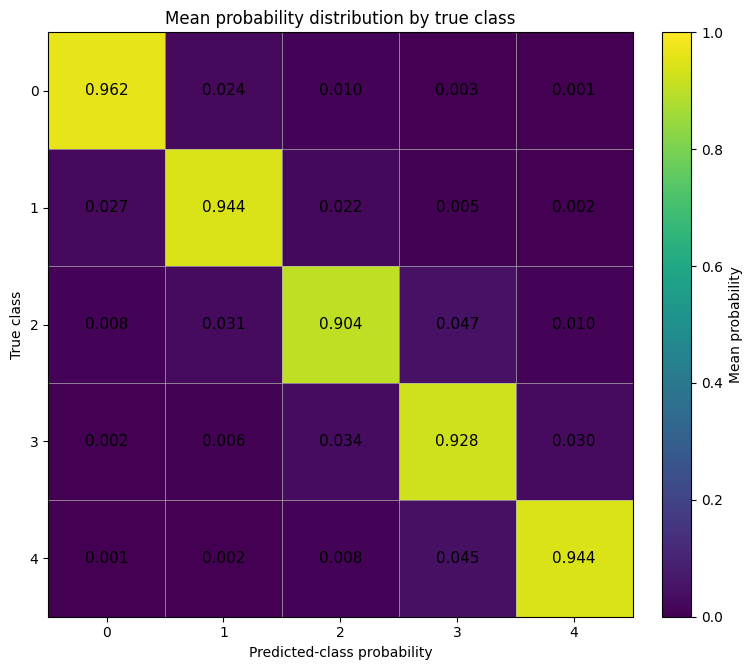

In [ ]:
def make_figure_06(targets: np.ndarray, probabilities: np.ndarray):
    matrix = np.zeros((5, 5))

    for true_class in range(5):
        matrix[true_class] = probabilities[targets == true_class].mean(0)

    fig, axis = plt.subplots(figsize=(6.4, 5.6))
    image = axis.imshow(matrix, vmin=0, vmax=1, aspect="equal")

    for row in range(5):
        for column in range(5):
            axis.text(
                column,
                row,
                f"{matrix[row, column]:.3f}",
                ha="center",
                va="center",
            )

    axis.set_xticks(CLASS_IDS)
    axis.set_yticks(CLASS_IDS)
    axis.set_xlabel("Predicted-class probability")
    axis.set_ylabel("True class")
    axis.set_title("Mean probability distribution by true class")
    fig.colorbar(image, ax=axis, label="Mean probability")

    plt.tight_layout()
    save_figure(fig, "Figure_06_Class_Wise_Probability_Matrix")
    plt.show()
    return fig


figure_06 = make_figure_06(PRED["targets"], PRED["final"])

Saved: F:\Ml files\DR project\dr_hybrid_outputs\prediction_level_figures\Figure_07_Correct_Adjacent_Major_Error_Cases.png
Saved: F:\Ml files\DR project\dr_hybrid_outputs\prediction_level_figures\Figure_07_Correct_Adjacent_Major_Error_Cases.pdf
Saved: F:\Ml files\DR project\dr_hybrid_outputs\prediction_level_figures\Figure_07_Correct_Adjacent_Major_Error_Cases.svg


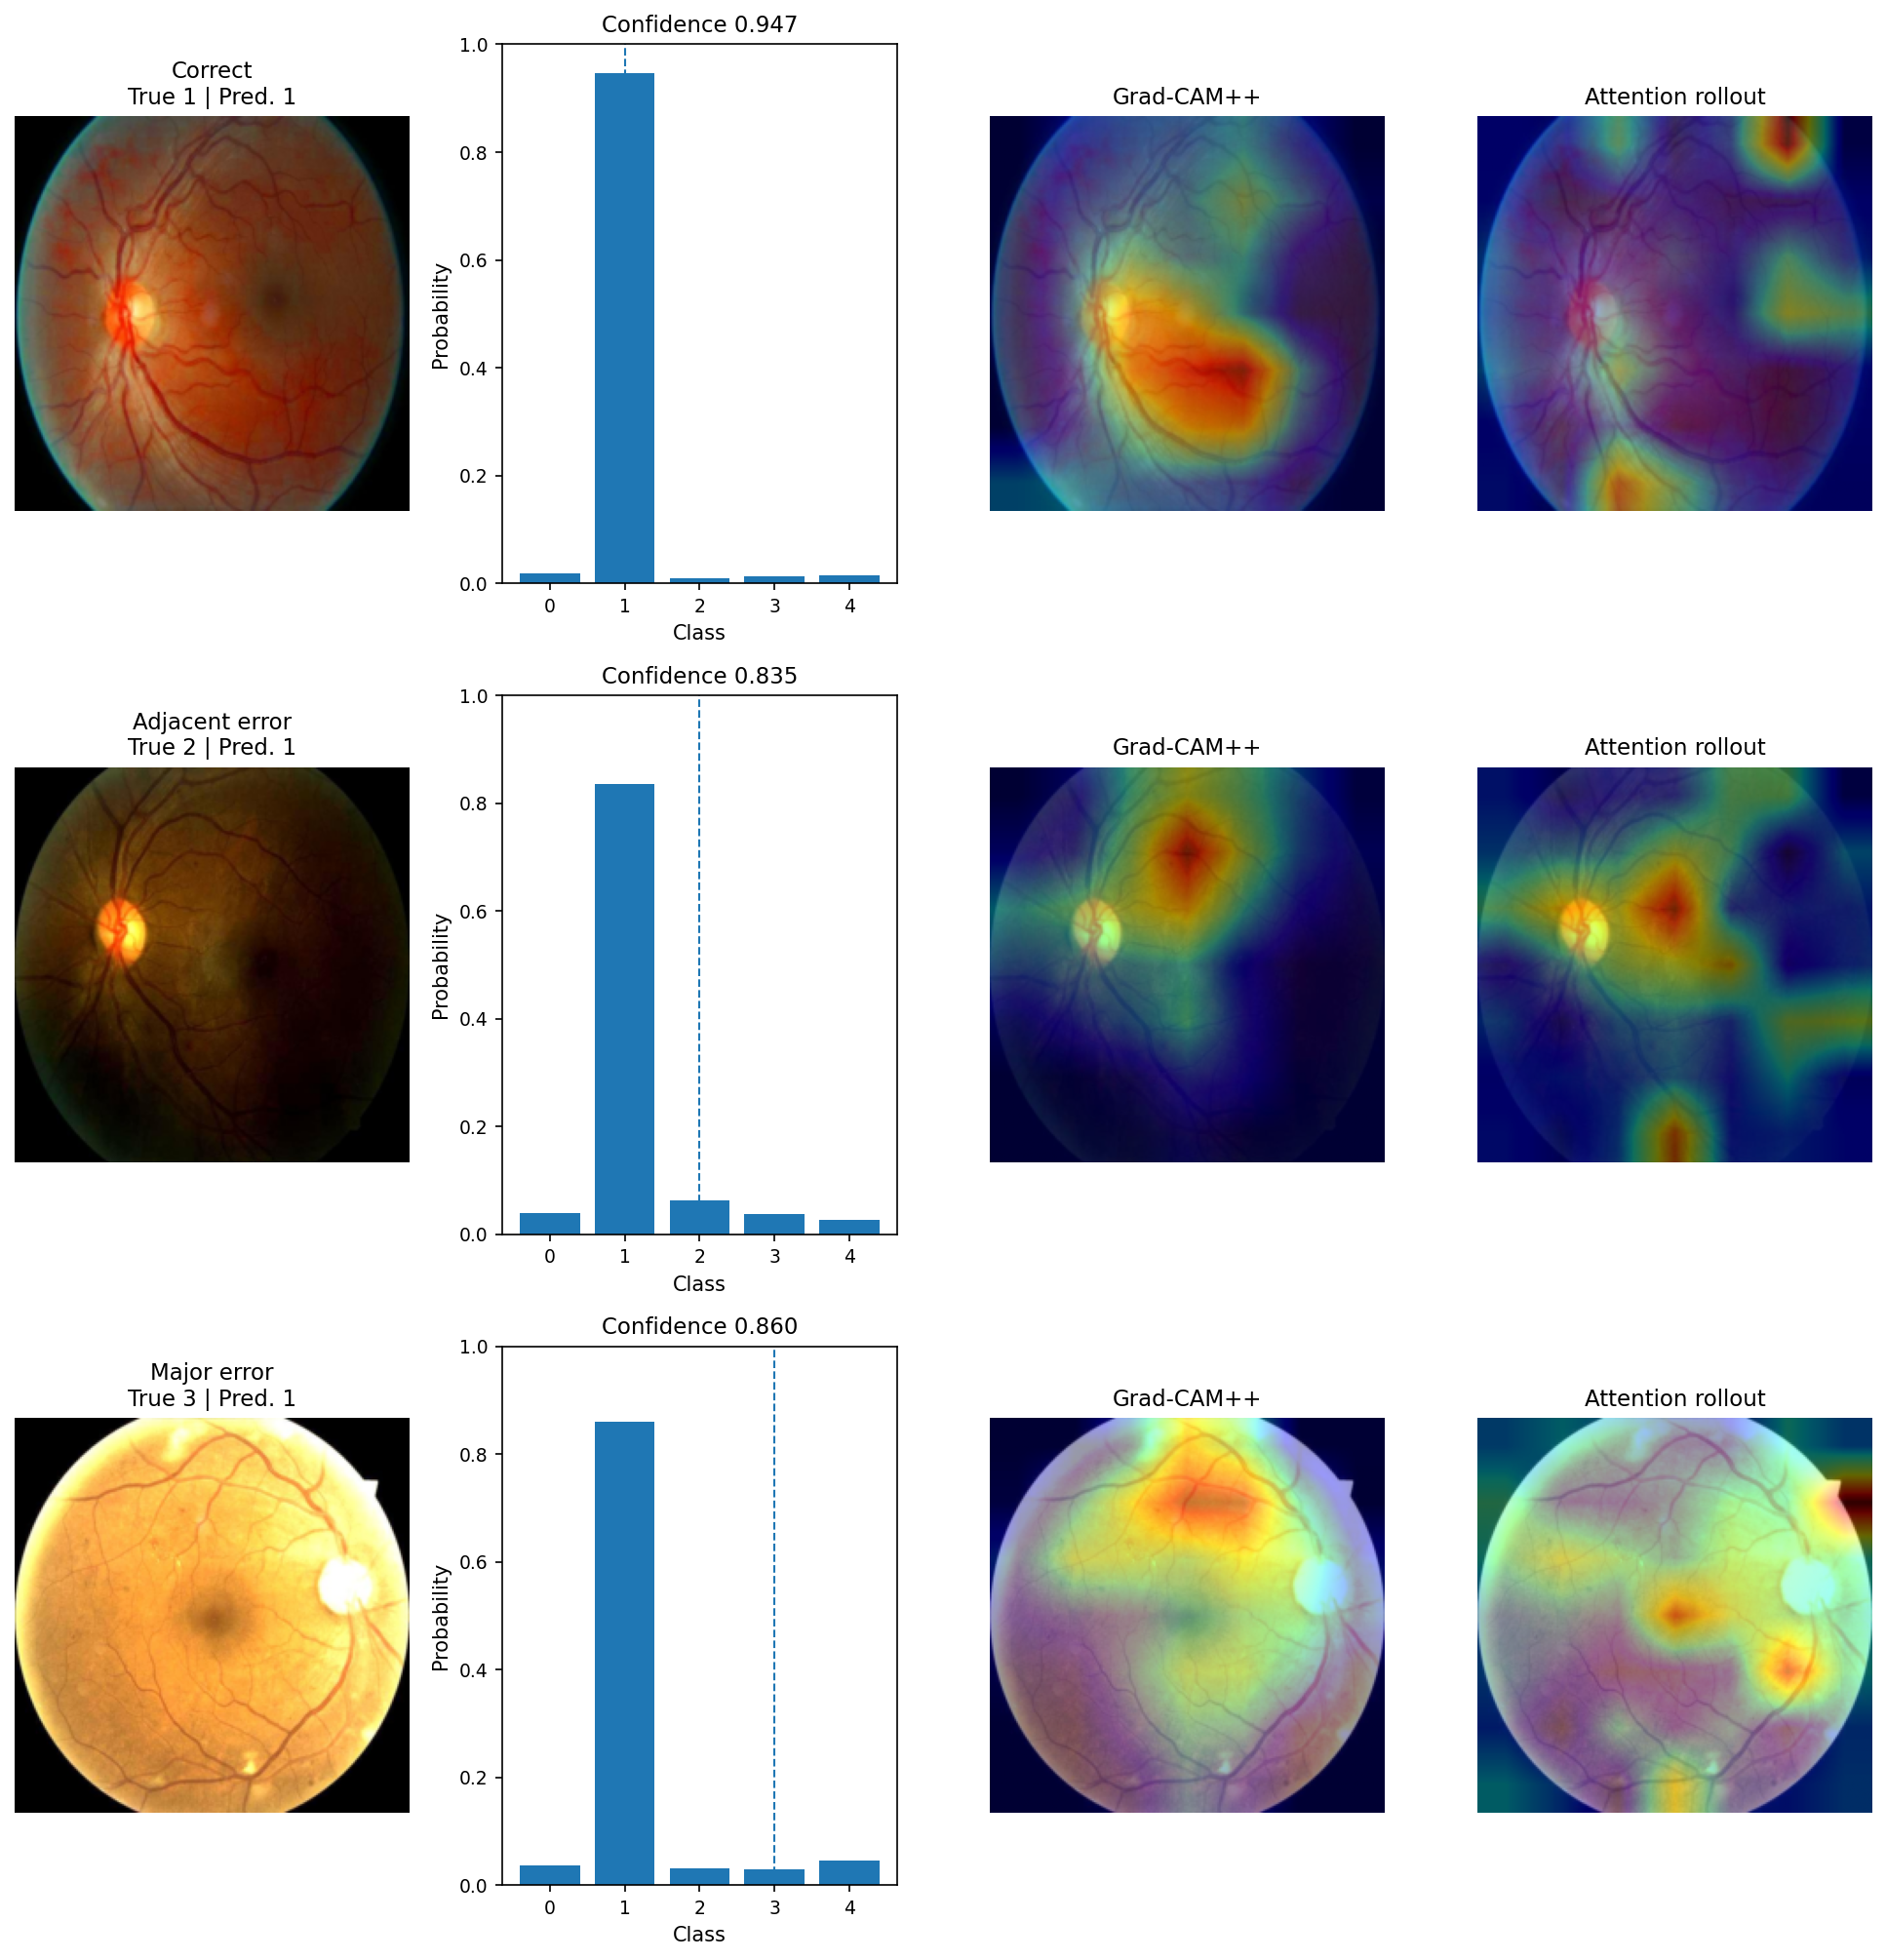

In [ ]:
def representative_cases(frame: pd.DataFrame):
    cases = []
    correct = frame[frame["absolute_error"] == 0]
    adjacent = frame[frame["absolute_error"] == 1]
    major = frame[frame["absolute_error"] >= 2]

    if not correct.empty:
        cases.append(("Correct", int(correct["confidence"].idxmax())))

    if not adjacent.empty:
        cases.append(("Adjacent error", int(adjacent["confidence"].idxmax())))

    if not major.empty:
        cases.append(("Major error", int(major["confidence"].idxmax())))
    elif not adjacent.empty:
        cases.append(
            (
                "Highest-uncertainty error",
                int(adjacent["entropy"].idxmax()),
            )
        )

    return cases


def make_figure_07(pred: Dict[str, Any]):
    cases = representative_cases(pred["frame"])

    if not cases:
        print("Figure 7 skipped: no representative cases.")
        return None

    fig, axes = plt.subplots(
        len(cases), 4, figsize=(13, 4.5 * len(cases)), squeeze=False
    )

    for r, (case_name, index) in enumerate(cases):
        sample = pred["frame"].loc[index]
        image = load_display_image(pred["paths"][index])
        gradcam, rollout = explanations(
            pred["paths"][index],
            int(sample["predicted_class"]),
        )

        axes[r, 0].imshow(image)
        axes[r, 0].axis("off")
        axes[r, 0].set_title(
            f"{case_name}\n"
            f"True {int(sample['true_class'])} | "
            f"Pred. {int(sample['predicted_class'])}"
        )

        probability_bars(
            axes[r, 1],
            pred["final"][index],
            f"Confidence {sample['confidence']:.3f}",
            int(sample["true_class"]),
        )

        axes[r, 2].imshow(overlay(image, gradcam))
        axes[r, 2].axis("off")
        axes[r, 2].set_title("Grad-CAM++")

        axes[r, 3].imshow(overlay(image, rollout))
        axes[r, 3].axis("off")
        axes[r, 3].set_title("Attention rollout")

    plt.tight_layout()
    save_figure(fig, "Figure_07_Correct_Adjacent_Major_Error_Cases")
    plt.show()
    return fig


figure_07 = make_figure_07(PRED)

Saved: F:\Ml files\DR project\dr_hybrid_outputs\prediction_level_figures\Figure_08_Prediction_Stability_Perturbations.png
Saved: F:\Ml files\DR project\dr_hybrid_outputs\prediction_level_figures\Figure_08_Prediction_Stability_Perturbations.pdf
Saved: F:\Ml files\DR project\dr_hybrid_outputs\prediction_level_figures\Figure_08_Prediction_Stability_Perturbations.svg


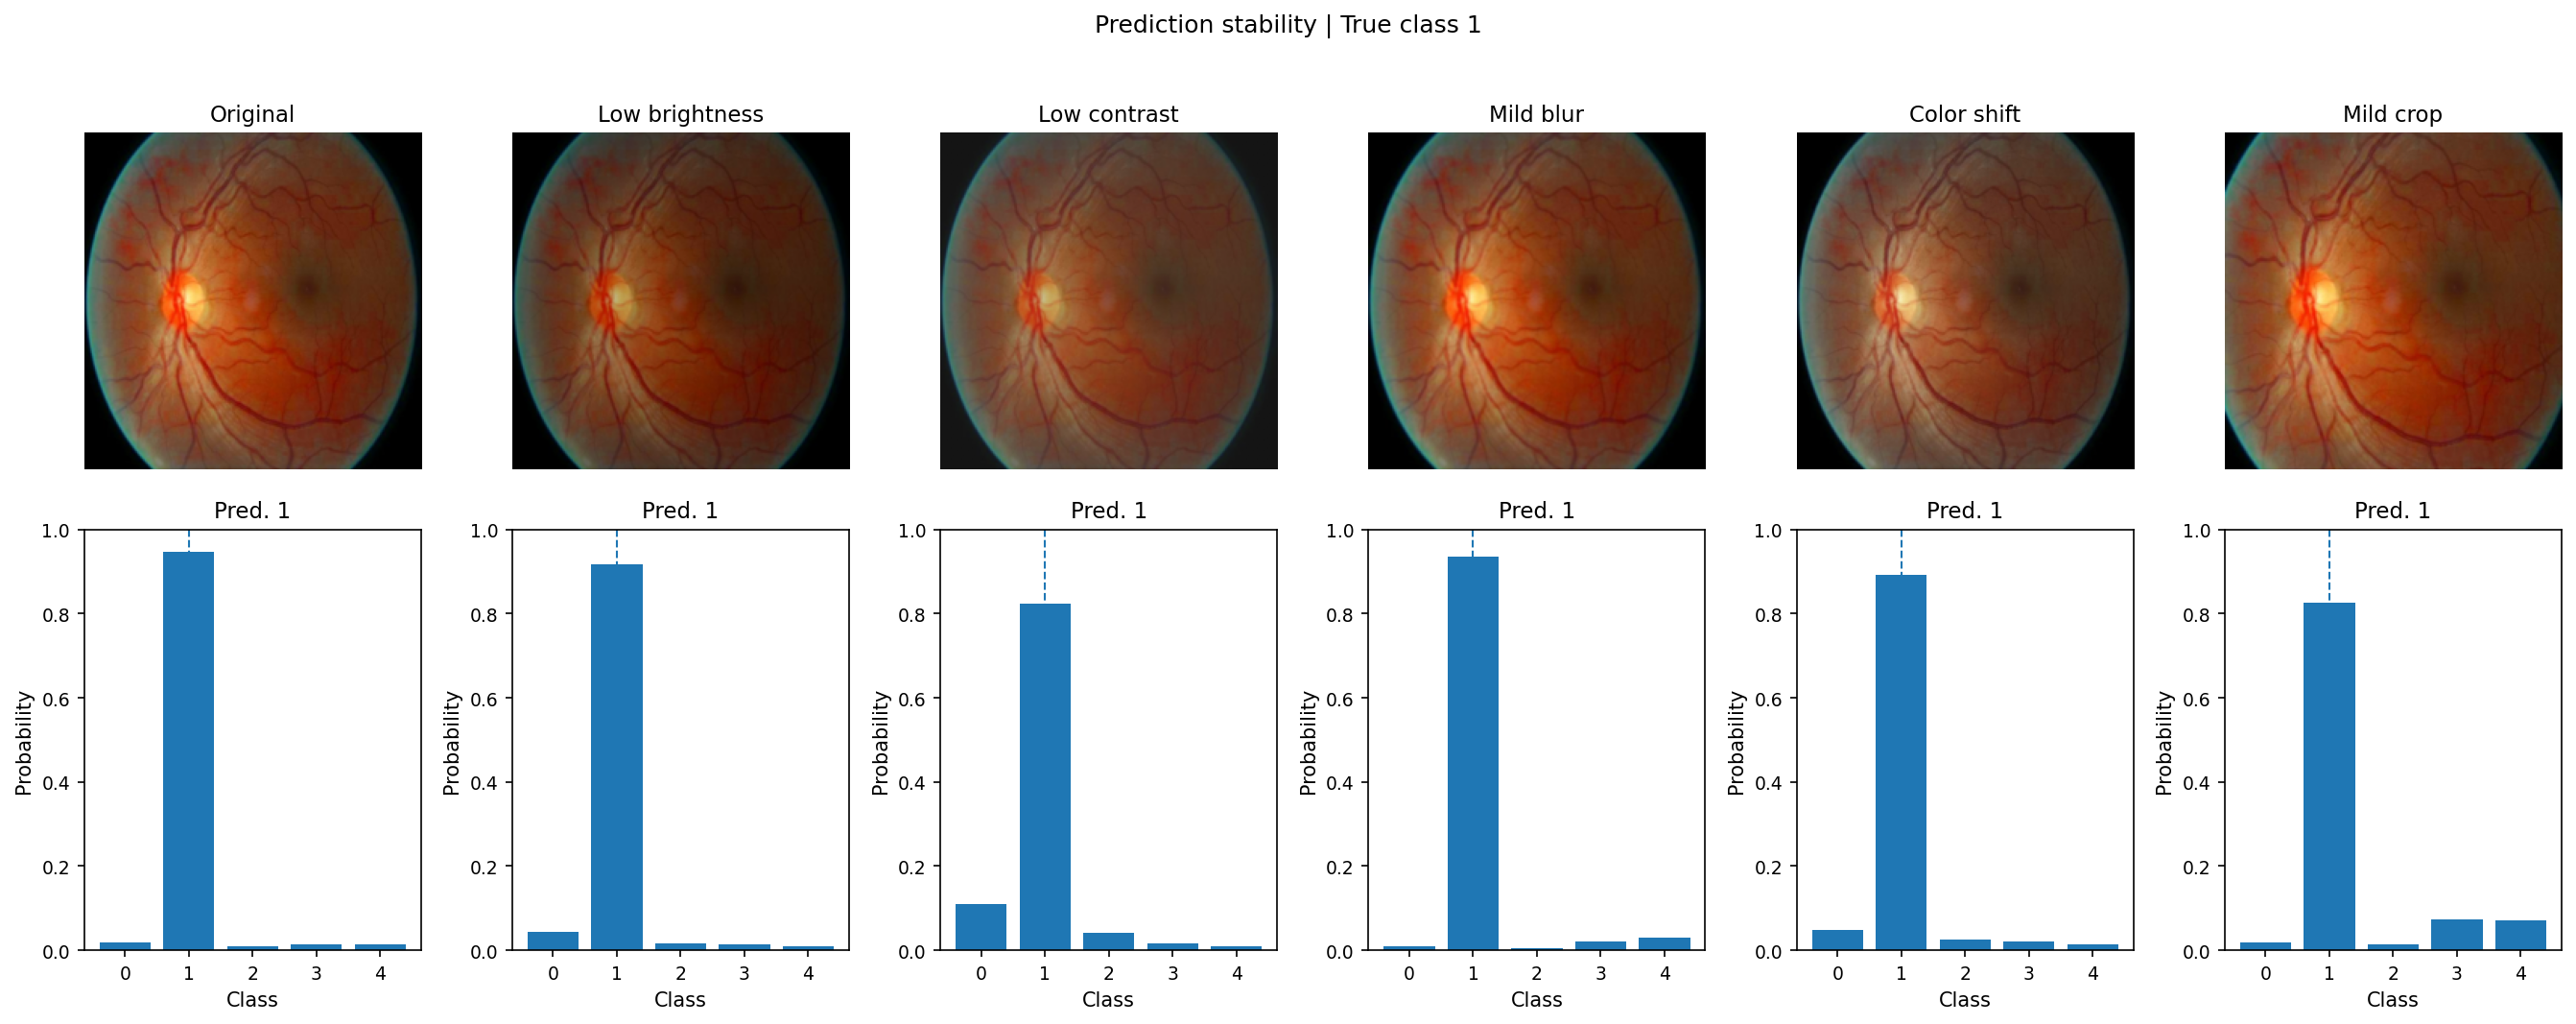

In [ ]:
def perturbations(image: Image.Image):
    image = image.convert("RGB")
    width, height = image.size
    margin = int(min(width, height) * 0.06)

    cropped = image.crop(
        (margin, margin, width - margin, height - margin)
    ).resize(image.size, Image.Resampling.BILINEAR)

    return {
        "Original": image,
        "Low brightness": ImageEnhance.Brightness(image).enhance(0.75),
        "Low contrast": ImageEnhance.Contrast(image).enhance(0.70),
        "Mild blur": image.filter(ImageFilter.GaussianBlur(1.2)),
        "Color shift": ImageEnhance.Color(image).enhance(0.70),
        "Mild crop": cropped,
    }


@torch.inference_mode()
def predict_pil(image: Image.Image):
    tensor = eval_transform(image).unsqueeze(0).to(DEVICE)
    return torch.softmax(model(tensor), dim=1).cpu().numpy()[0]


def make_figure_08(pred: Dict[str, Any]):
    correct = pred["frame"][pred["frame"]["absolute_error"] == 0]
    index = int(
        correct["confidence"].idxmax()
        if not correct.empty
        else pred["frame"].index[0]
    )

    path = pred["frame"].loc[index, "image_path"]
    true_class = int(pred["frame"].loc[index, "true_class"])
    variants = perturbations(Image.open(path).convert("RGB"))
    variant_probabilities = {
        name: predict_pil(image)
        for name, image in variants.items()
    }

    fig, axes = plt.subplots(2, len(variants), figsize=(18, 7))

    for column, (name, image) in enumerate(variants.items()):
        display_image = np.asarray(
            image.resize(
                (
                    int(getattr(globals().get("CFG", None), "image_size", 224)),
                    int(getattr(globals().get("CFG", None), "image_size", 224)),
                ),
                Image.Resampling.BILINEAR,
            ),
            dtype=np.float32,
        ) / 255.0

        axes[0, column].imshow(display_image)
        axes[0, column].axis("off")
        axes[0, column].set_title(name)

        probability_bars(
            axes[1, column],
            variant_probabilities[name],
            f"Pred. {variant_probabilities[name].argmax()}",
            true_class,
        )

    fig.suptitle(
        f"Prediction stability | True class {true_class}",
        y=1.01,
    )
    plt.tight_layout()
    save_figure(fig, "Figure_08_Prediction_Stability_Perturbations")
    plt.show()
    return fig


figure_08 = make_figure_08(PRED)

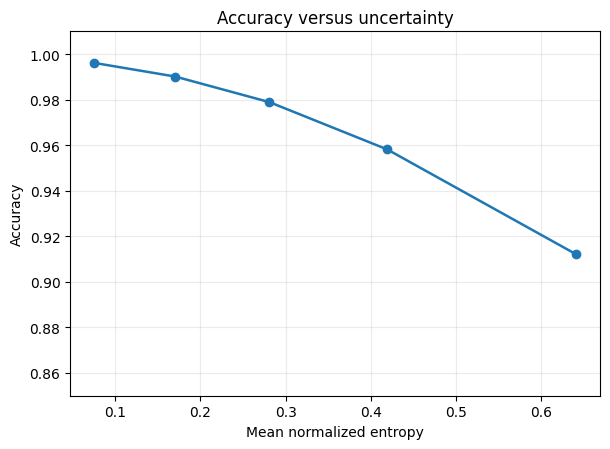

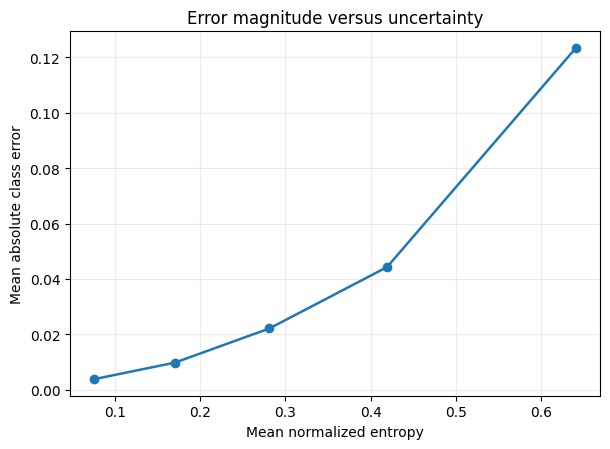

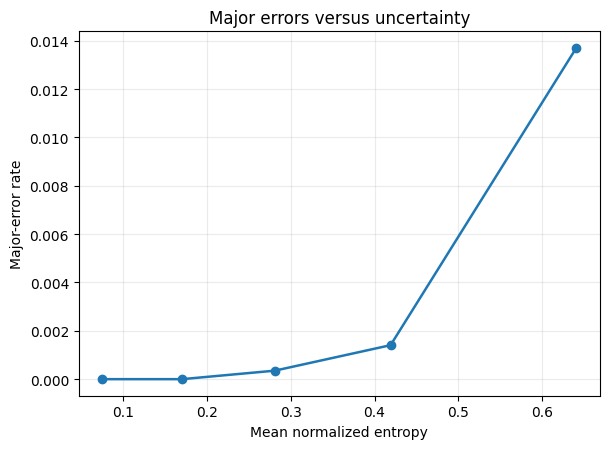

,group,mean_entropy,accuracy,mean_absolute_error,major_error_rate,n
0,Lowest,0.075496,0.996135,0.003865,0.000000,2846
1,Low,0.170392,0.990158,0.009842,0.000000,2845
2,Medium,0.281068,0.978910,0.022144,0.000351,2845
3,High,0.419154,0.958172,0.044288,0.001406,2845
4,Highest,0.640696,0.912157,0.123331,0.013703,2846


In [ ]:
def make_figure_09(frame: pd.DataFrame):
    analysis = frame.copy()
    analysis["uncertainty_group"] = pd.qcut(
        analysis["entropy"],
        q=5,
        labels=["Lowest", "Low", "Medium", "High", "Highest"],
        duplicates="drop",
    )

    rows = []
    for group_name, group in analysis.groupby(
        "uncertainty_group", observed=False
    ):
        rows.append(
            {
                "group": str(group_name),
                "mean_entropy": group["entropy"].mean(),
                "accuracy": (
                    group["true_class"] == group["predicted_class"]
                ).mean(),
                "mean_absolute_error": group["absolute_error"].mean(),
                "major_error_rate": (
                    group["absolute_error"] >= 2
                ).mean(),
            }
        )

    summary = pd.DataFrame(rows)

    fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

    axes[0].plot(
        summary["mean_entropy"], summary["accuracy"], marker="o"
    )
    axes[0].set_xlabel("Mean normalized entropy")
    axes[0].set_ylabel("Accuracy")
    axes[0].set_title("Accuracy versus uncertainty")

    axes[1].plot(
        summary["mean_entropy"],
        summary["mean_absolute_error"],
        marker="o",
    )
    axes[1].set_xlabel("Mean normalized entropy")
    axes[1].set_ylabel("Mean absolute class error")
    axes[1].set_title("Error magnitude versus uncertainty")

    axes[2].plot(
        summary["mean_entropy"],
        summary["major_error_rate"],
        marker="o",
    )
    axes[2].set_xlabel("Mean normalized entropy")
    axes[2].set_ylabel("Major-error rate")
    axes[2].set_title("Major errors versus uncertainty")

    for axis, label in zip(axes, ("(a)", "(b)", "(c)")):
        panel_label(axis, label)

    plt.tight_layout()
    # save_figure(fig, "Figure_09_Uncertainty_Error_Correspondence")
    plt.show()
    display(summary)
    return fig


figure_09 = make_figure_09(PRED["frame"])

In [ ]:
from pathlib import Path
from typing import Dict, List

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import auc, roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize

# ----------------------------- EDIT HERE -----------------------------
OUTPUT_DIRECTORY = Path("F:\\Ml files\\DR project\\dr_hybrid_outputs")
HISTORY_CSV = OUTPUT_DIRECTORY / "training_history.csv"
PREDICTIONS_CSV = OUTPUT_DIRECTORY / "test_predictions.csv"
FIGURE_DIRECTORY = OUTPUT_DIRECTORY / "learning_and_roc_figures"
# ---------------------------------------------------------------------

FIGURE_DIRECTORY.mkdir(parents=True, exist_ok=True)

CLASS_IDS = np.arange(5)
CLASS_NAMES = {
    0: "No DR",
    1: "Mild",
    2: "Moderate",
    3: "Severe",
    4: "Proliferative DR",
}
EXPORT_DPI = 600

plt.rcParams.update(
    {
        "font.family": "DejaVu Sans",
        "font.size": 11,
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 9,
        "figure.dpi": 150,
        "savefig.bbox": "tight",
    }
)

def save_figure(figure: plt.Figure, stem: str) -> None:
    for extension in ("png", "pdf", "svg"):
        path = FIGURE_DIRECTORY / f"{stem}.{extension}"
        if extension == "png":
            figure.savefig(path, dpi=EXPORT_DPI)
        else:
            figure.savefig(path)
        print("Saved:", path)

def require_columns(frame: pd.DataFrame, columns: List[str], name: str) -> None:
    missing = [column for column in columns if column not in frame.columns]
    if missing:
        raise ValueError(f"{name} is missing columns: {missing}")

In [ ]:
if not PREDICTIONS_CSV.exists():
    raise FileNotFoundError(f"Prediction file not found: {PREDICTIONS_CSV}")

predictions = pd.read_csv(PREDICTIONS_CSV)

probability_columns = [
    f"probability_class_{class_id}"
    for class_id in CLASS_IDS
]

require_columns(
    predictions,
    ["true_class", *probability_columns],
    "Test-prediction CSV",
)

true_classes = predictions["true_class"].to_numpy(dtype=int)
probabilities = predictions[probability_columns].to_numpy(dtype=float)

if probabilities.shape[1] != 5:
    raise ValueError(f"Expected five probability columns, got {probabilities.shape[1]}.")

if np.any(probabilities < 0) or np.any(probabilities > 1):
    raise ValueError("Probability values must be between 0 and 1.")

row_sums = probabilities.sum(axis=1)
if not np.allclose(row_sums, 1.0, atol=1e-3):
    probabilities = probabilities / np.clip(row_sums[:, None], 1e-12, None)

binary_targets = label_binarize(true_classes, classes=CLASS_IDS)

fpr: Dict[int | str, np.ndarray] = {}
tpr: Dict[int | str, np.ndarray] = {}
auc_values: Dict[int | str, float] = {}

for class_id in CLASS_IDS:
    fpr[class_id], tpr[class_id], _ = roc_curve(
        binary_targets[:, class_id],
        probabilities[:, class_id],
    )
    auc_values[class_id] = auc(fpr[class_id], tpr[class_id])

# Micro-average ROC.
fpr["micro"], tpr["micro"], _ = roc_curve(
    binary_targets.ravel(),
    probabilities.ravel(),
)
auc_values["micro"] = auc(fpr["micro"], tpr["micro"])

# Macro-average ROC.
shared_fpr = np.unique(
    np.concatenate([fpr[class_id] for class_id in CLASS_IDS])
)
mean_tpr = np.zeros_like(shared_fpr)

for class_id in CLASS_IDS:
    mean_tpr += np.interp(shared_fpr, fpr[class_id], tpr[class_id])

mean_tpr /= len(CLASS_IDS)
fpr["macro"] = shared_fpr
tpr["macro"] = mean_tpr
auc_values["macro"] = auc(fpr["macro"], tpr["macro"])

weighted_auc = roc_auc_score(
    true_classes,
    probabilities,
    labels=CLASS_IDS,
    multi_class="ovr",
    average="weighted",
)

print(f"Macro-average ROC-AUC: {auc_values['macro']:.4f}")
print(f"Micro-average ROC-AUC: {auc_values['micro']:.4f}")
print(f"Weighted OvR ROC-AUC: {weighted_auc:.4f}")

Macro-average ROC-AUC: 0.9954
Micro-average ROC-AUC: 0.9961
Weighted OvR ROC-AUC: 0.9957


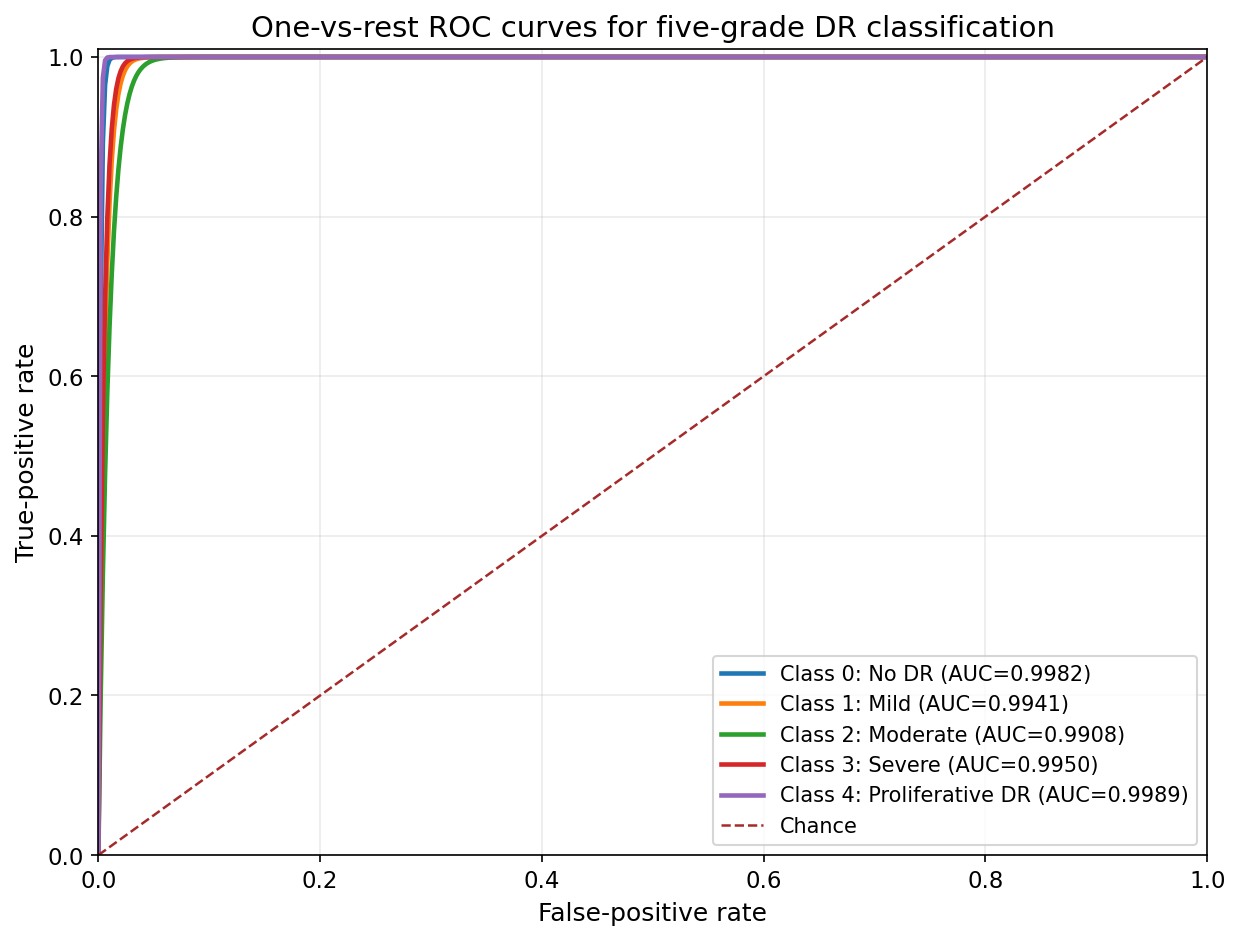

In [ ]:
# One-vs-rest ROC curves.
figure = plt.figure(figsize=(8.2, 6.5))
axis = plt.gca()

for class_id in CLASS_IDS:
    axis.plot(
        fpr[class_id],
        tpr[class_id],
        linewidth=1.8,
        label=(
            f"Class {class_id}: {CLASS_NAMES[class_id]} "
            f"(AUC={auc_values[class_id]:.3f})"
        ),
    )

axis.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1,
    label="Chance",
)

axis.set_xlabel("False-positive rate")
axis.set_ylabel("True-positive rate")
axis.set_title("One-vs-rest ROC curves for five-grade DR classification")
axis.set_xlim(0, 1)
axis.set_ylim(0, 1.01)
axis.grid(alpha=0.25)
axis.legend(loc="lower right")

plt.tight_layout()
save_figure(figure, "Figure_ROC_AUC_Per_Class")
plt.show()

In [ ]:
auc_summary = pd.DataFrame(
    [
        {
            "analysis": f"Class {class_id}",
            "clinical_grade": CLASS_NAMES[class_id],
            "roc_auc": auc_values[class_id],
        }
        for class_id in CLASS_IDS
    ]
    + [
        {
            "analysis": "Macro average",
            "clinical_grade": "All classes",
            "roc_auc": auc_values["macro"],
        },
        {
            "analysis": "Micro average",
            "clinical_grade": "All decisions",
            "roc_auc": auc_values["micro"],
        },
        {
            "analysis": "Weighted OvR",
            "clinical_grade": "Support weighted",
            "roc_auc": weighted_auc,
        },
    ]
)

auc_summary_path = FIGURE_DIRECTORY / "ROC_AUC_Summary.csv"
auc_summary.to_csv(auc_summary_path, index=False)

display(auc_summary.style.format({"roc_auc": "{:.4f}"}))
print("Saved:", auc_summary_path)

analysis,clinical_grade,roc_auc
Class 0,No DR,0.9982
Class 1,Mild,0.9941
Class 2,Moderate,0.9908
Class 3,Severe,0.9950
Class 4,Proliferative DR,0.9989
Macro average,All classes,0.9954
Micro average,All decisions,0.9961
Weighted OvR,Support weighted,0.9957



In [ ]:
validation_result = None
test_result = None
temperature_scaler = None
calibrated_test_probabilities = None
calibrated_metrics = None
calibrated_class_metrics = None
calibrated_cm = None

if (
    CFG.checkpoint_path.exists()
    and val_loader is not None
    and test_loader is not None
):
    validation_result = collect_predictions(
        model,
        val_loader,
        criterion,
        fast_dev_run=CFG.fast_dev_run,
        fast_dev_batches=CFG.fast_dev_batches,
    )

    test_result = collect_predictions(
        model,
        test_loader,
        criterion,
        fast_dev_run=CFG.fast_dev_run,
        fast_dev_batches=CFG.fast_dev_batches,
    )

    temperature_scaler = TemperatureScaler().to(DEVICE)
    temperature_scaler.fit(
        validation_result["logits"].to(DEVICE),
        validation_result["labels"].to(DEVICE),
    )

    with torch.no_grad():
        calibrated_test_logits = temperature_scaler(
            test_result["logits"].to(DEVICE)
        ).cpu()

        calibrated_test_probabilities = torch.softmax(
            calibrated_test_logits,
            dim=1,
        ).numpy()

    (
        calibrated_metrics,
        calibrated_class_metrics,
        calibrated_cm,
    ) = compute_classification_metrics(
        test_result["labels"].numpy(),
        calibrated_test_probabilities,
    )

    comparison = pd.DataFrame(
        {
            "uncalibrated": test_result["metrics"],
            "temperature_scaled": calibrated_metrics,
        }
    )
    display(comparison)
    print(
        "Learned temperature:",
        float(
            temperature_scaler.temperature.item()
        ),
    )
    display(calibrated_class_metrics)
else:
    print(
        "Test evaluation skipped because a checkpoint "
        "or data loader is unavailable."
    )

,uncalibrated,temperature_scaled
accuracy,0.9640,0.9640
macro_precision,0.9678,0.9678
macro_recall,0.9600,0.9600
macro_f1,0.9630,0.9630
qwk,0.9790,0.9790
macro_roc_auc_ovr,0.9954,0.9954
macro_pr_auc,0.9858,0.9858
major_error_rate,0.0031,0.0031
ece_15,0.0610,0.0240
multiclass_brier,0.0660,0.0580


,class_id,class_name,precision,sensitivity_recall,specificity,f1_score
0,0,No DR,0.982,0.978,0.989,0.980
1,1,Mild,0.949,0.936,0.991,0.942
2,2,Moderate,0.958,0.955,0.984,0.956
3,3,Severe,0.961,0.948,0.997,0.954
4,4,Proliferative DR,0.989,0.983,0.998,0.986
